

Case Study 1
¶


Model selection for Clustering
¶


Clustering is unsupervised learning: the resulting clusters are completely derived from data distributed in given a feature set with no class available


Compared to supervised learning counterparts, it is …




hard to define model performance (cluster quality)


sensitive to different clustering algorithms and different feature spaces.




Task
¶


Your task is to try different clustering algorithms and also a range of the potential parameter(s) which affect the number of clusters including ..




K-means 
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html


Gaussian Mixture Model, 
https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html#sklearn.mixture.GaussianMixture


Hierarchical Clustering, 
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html#sklearn.cluster.AgglomerativeClustering


Louvain Clustering, 
https://scikit-network.readthedocs.io/en/latest/reference/clustering.html#module-sknetwork.clustering




on 5K colorectal patches represented by 4 different representation PathologyGAN, ResNet50, InceptionV3 and VGG16


Data and its preprocessing
¶


5,000 non-overlapping image patches from hematoxylin & eosin (H&E) stained histological images of human colorectal cancer (CRC) and normal tissue.




4 feature sets, PathologyGAN, ResNet50, InceptionV3 and VGG16, are extracted to represent those 5,000 images different dimensional feature spaces.


PCA and UMAP were employed to reduce each feature sapce into 100-dimensional vectors
 


9 tissue types are also available which include Adipose (ADI), background (BACK), debris (DEB), lymphocytes (LYM), mucus (MUC), smooth muscle (MUS), normal colon mucosa (NORM), cancer-associated stroma (STR), colorectal adenocarcinoma epithelium (TUM)
 




Performance Measurement
¶


To assess quality of clustering solutions, several approaches are expected to be done and interpreted which include...




Silhouette Score for goodness of fit test


Vmeasure Score for homogeneity and completeness test (tissue type available as ground truth)


Clusters visualisations




For more information, please have a check... 
https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation


Report
¶


Report on your preprocessing pipeline, theory and intuition behinds each algorithm and representation, parameter searching and performance evaluation frameworks. If there is any addiotional process, give evidences/justifications on how it helps.





Required Packages
¶



In [148]:
# import sys

# !{sys.executable} -m pip uninstall -y scikit-learn sklearn
# !{sys.executable} -m pip install scikit-learn==1.3.2

# !{sys.executable} -m pip uninstall -y h5py
# !{sys.executable} -m pip install h5py==3.8.0

# !{sys.executable} -m pip install numpy

# !{sys.executable} -m pip install pandas
# !{sys.executable} -m pip install scikit-network
# !{sys.executable} -m pip install pickle-mixin==1.0.2
# !{sys.executable} -m pip install matplotlib
# !{sys.executable} -m pip install plotly




Prepare Tissue Representations
¶



In [149]:
import h5py
import numpy as np
import pickle


In [150]:
pge_path = 'colon_nct_feature/pge_dim_reduced_feature.h5'
resnet50_path = 'colon_nct_feature/resnet50_dim_reduced_feature.h5'
inceptionv3_path = 'colon_nct_feature/inceptionv3_dim_reduced_feature.h5'
vgg16_path = 'colon_nct_feature/vgg16_dim_reduced_feature.h5'

pge_content = h5py.File(pge_path, mode='r')
resnet50_content = h5py.File(resnet50_path, mode='r')
inceptionv3_content = h5py.File(inceptionv3_path, mode='r')
vgg16_content = h5py.File(vgg16_path, mode='r')


In [151]:
vgg16_content


<HDF5 file "vgg16_dim_reduced_feature.h5" (mode r)>

In [152]:
#PCA feature from 4 feature sets: pge_latent, resnet50_latent, inceptionv3_latent, vgg16_latent
pge_pca_feature  = pge_content['pca_feature'][...]
resnet50_pca_feature  = resnet50_content['pca_feature'][...]
inceptionv3_pca_feature = inceptionv3_content['pca_feature'][...]
vgg16_pca_feature  = vgg16_content['pca_feature'][...]


In [153]:
vgg16_pca_feature


array([[ -90.864815 ,  107.03243  ,  116.16385  , ...,    8.259951 ,
          -1.1383446,   -9.175951 ],
       [ -74.06226  ,  117.31615  ,   95.24547  , ...,   -1.9739974,
           6.8172655,    4.2547903],
       [ -81.875336 ,  122.84872  ,   83.767784 , ...,   -1.3287221,
          13.65623  ,  -11.109545 ],
       ...,
       [  32.70835  ,   31.183935 ,  -47.30978  , ...,    4.2004256,
           3.599823 ,    6.0058775],
       [ -39.911785 , -105.81029  ,  122.37118  , ...,  -14.908715 ,
          -1.1814455,  -10.837135 ],
       [  32.35425  ,  -50.3373   ,   66.50197  , ...,   -3.859397 ,
          -1.047523 ,    2.3827858]], dtype=float32)

In [154]:
#UMAP feature from 4 feature sets: pge_latent, resnet50_latent, inceptionv3_latent, vgg16_latent
pge_umap_feature  = pge_content['umap_feature'][...]
resnet50_umap_feature = resnet50_content['umap_feature'][...]
inceptionv3_umap_feature  = inceptionv3_content['umap_feature'][...]
vgg16_umap_feature  = vgg16_content['umap_feature'][...]


In [155]:
#tissue type as available ground-truth: labels
filename  = np.squeeze(pge_content['file_name'])
filename = np.array([str(x) for x in filename])
labels = np.array([x.split('/')[2] for x in filename])
labels


array(['ADI', 'ADI', 'ADI', ..., 'TUM', 'TUM', 'TUM'], dtype='<U4')



Example
¶



In [156]:
import random


In [157]:
random.seed(0)
selected_index = random.sample(list(np.arange(len(pge_pca_feature))), 200)


In [158]:
test_data = pge_pca_feature[selected_index]
test_label = labels[selected_index]




Exploratory Analysis
¶



In [159]:
import plotly.graph_objects as go
import pandas as pd


In [160]:
traces = []
for name in np.unique(labels):
    trace = go.Scatter3d(
        x=test_data[test_label==name,0],
        y=test_data[test_label==name,1],
        z=test_data[test_label==name,2],
        mode='markers',
        name=name,
        marker=go.scatter3d.Marker(
            size=4,
            opacity=0.8
        )

    )
    traces.append(trace)


# data = go.Data(traces)
# layout = go.Layout(
#             showlegend=True,
#     scene=go.Scene(
#                 xaxis=go.layout.scene.XAxis(title='PC1'),
#                 yaxis=go.layout.scene.YAxis(title='PC2'),
#                 zaxis=go.layout.scene.ZAxis(title='PC3')
#                 )
# )
# fig = go.Figure(data=data, layout=layout)
# fig.update_layout(
#     title="First 3 pricipal components of PathologyGAN's PCA feature",
#     legend_title="Legend Title",
# )

# fig.show()




Model training
¶



In [161]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sknetwork.clustering import Louvain


In [162]:
#to create Adjacency matrix for  Louvain clustering
from sklearn.metrics import pairwise_distances 
from sklearn.preprocessing import MinMaxScaler


In [163]:
kmeans_model = KMeans(n_clusters = 9, random_state = 0) #GaussianMixture(), AgglomerativeClustering(), Louvain
kmeans_assignment = kmeans_model.fit_predict(test_data)


c:\Users\BehShuAo\anaconda3\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



In [164]:
from scipy import sparse

louvain_model = Louvain(resolution = 0.5, modularity = 'newman', random_state = 0)
adjacency_matrix = sparse.csr_matrix(MinMaxScaler().fit_transform(pairwise_distances(test_data)))
louvain_assignment = louvain_model.fit_predict(adjacency_matrix)




Evaluation and Visualisation
¶



In [165]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, v_measure_score
from sklearn.model_selection import KFold, train_test_split






check out number of clusters/cluster assignment counts





In [166]:
print('Number of clusters from KMeans: %d and from Louvain: %d'%(np.unique(kmeans_assignment).shape[0],np.unique(louvain_assignment).shape[0]))


Number of clusters from KMeans: 9 and from Louvain: 1


In [167]:
kmeans_counts = np.unique(kmeans_assignment, return_counts = True)
louvain_counts = np.unique(louvain_assignment, return_counts = True)


In [168]:
print('Kmeans assignment counts')
pd.DataFrame({'Cluster Index': kmeans_counts[0], 'Number of members':kmeans_counts[1]}).set_index('Cluster Index')


Kmeans assignment counts


,Number of members
Cluster Index,
0,16
1,32
2,24
3,22
4,30
5,25
6,18
7,30
8,3


In [169]:
print('Louvain assignment counts')
pd.DataFrame({'Cluster Index': louvain_counts[0], 'Number of members':louvain_counts[1]}).set_index('Cluster Index')


Louvain assignment counts


,Number of members
Cluster Index,
0,200






Assess goodness of fit by silhouette score and cluster homogeneities by V-measure





In [170]:
kmeans_silhouette = silhouette_score(test_data, kmeans_assignment)

louvain_silhouette = None

kmeans_v_measure = v_measure_score(test_label, kmeans_assignment)
louvain_v_measure = v_measure_score(test_label, louvain_assignment)

pd.DataFrame({
    'Metrics': ['silhouette', 'v-measure'],
    'KMeans': [kmeans_silhouette, kmeans_v_measure],
    'Louvain': [louvain_silhouette, louvain_v_measure]
}).set_index('Metrics')


,KMeans,Louvain
Metrics,,
silhouette,0.130553,NaN
v-measure,0.420753,0.0






Visualise tissue type percentage in two different clustering configurations





In [171]:
def calculate_percent(sub_df, attrib):
    cnt = sub_df[attrib].count()
    output_sub_df = sub_df.groupby(attrib).count()
    return (output_sub_df/cnt)


C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\975455919.py:2: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\975455919.py:16: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\975455919.py:27: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



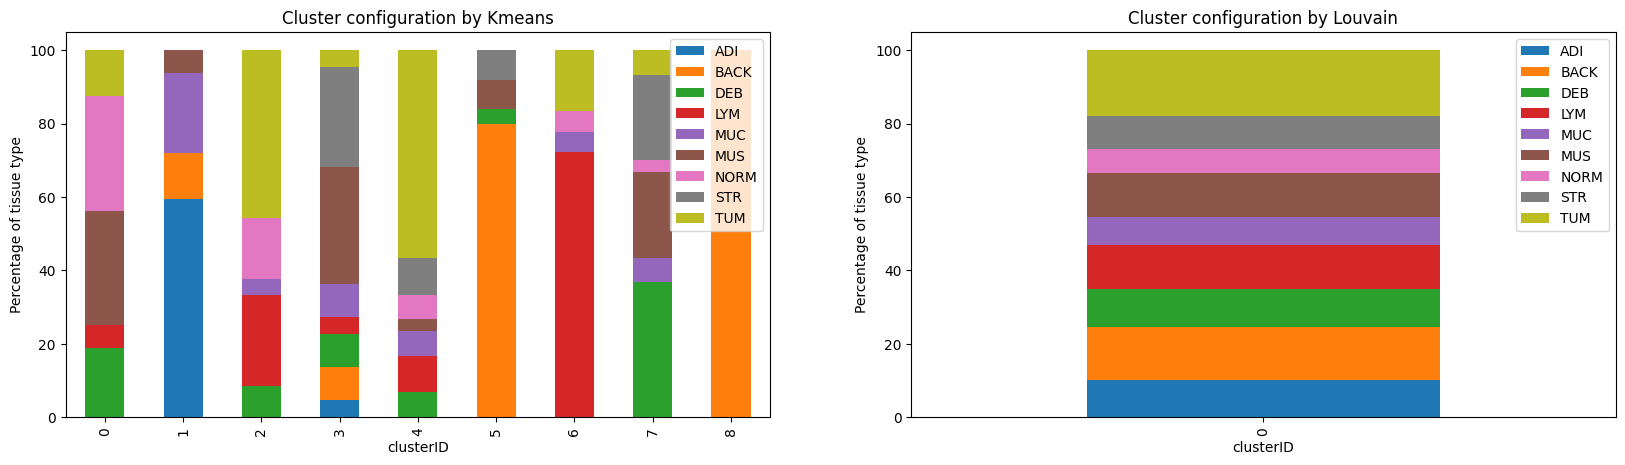

In [172]:
resulted_cluster_df = pd.DataFrame({'clusterID': kmeans_assignment, 'type': test_label})
label_proportion_df = resulted_cluster_df.groupby(['clusterID']).apply(lambda x: calculate_percent(x,'type')).rename(columns={'clusterID':'type_occurrence_percentage'}).reset_index()
pivoted_label_proportion_df = pd.pivot_table(label_proportion_df, index = 'clusterID', columns = 'type', values = 'type_occurrence_percentage')


f, axes = plt.subplots(1, 2, figsize=(20,5))
number_of_tile_df = resulted_cluster_df.groupby('clusterID')['type'].count().reset_index().rename(columns={'type':'number_of_tile'})
df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df*100).loc[df_idx].plot.bar(stacked=True, ax = axes[0] )

axes[0].set_ylabel('Percentage of tissue type')
axes[0].legend(loc='upper right')
axes[0].set_title('Cluster configuration by Kmeans')

resulted_cluster_df = pd.DataFrame({'clusterID': louvain_assignment, 'type': test_label})
label_proportion_df = resulted_cluster_df.groupby(['clusterID']).apply(lambda x: calculate_percent(x,'type')).rename(columns={'clusterID':'type_occurrence_percentage'}).reset_index()
pivoted_label_proportion_df = pd.pivot_table(label_proportion_df, index = 'clusterID', columns = 'type', values = 'type_occurrence_percentage')


number_of_tile_df = resulted_cluster_df.groupby('clusterID')['type'].count().reset_index().rename(columns={'type':'number_of_tile'})
df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df*100).loc[df_idx].plot.bar(stacked=True, ax = axes[1] )

axes[1].set_ylabel('Percentage of tissue type')
axes[1].legend(loc='upper right')
axes[1].set_title('Cluster configuration by Louvain')
f.show()


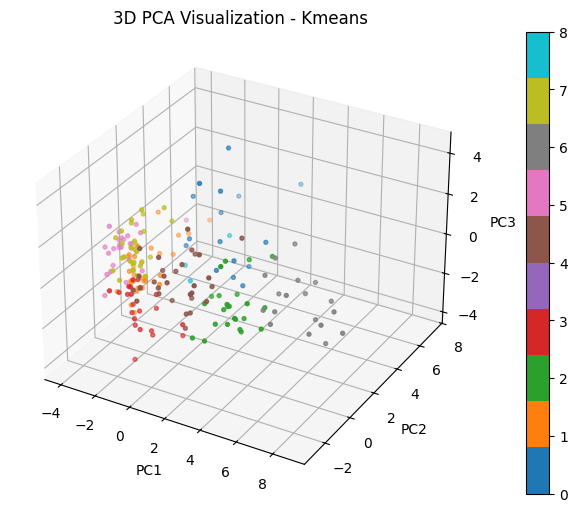

In [173]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Perform PCA with 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(test_data)

# Plot 3D PCA
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    pca_result[:, 2],
    c=kmeans_assignment,   # or louvain_assignment
    cmap='tab10',
    s=8
)

ax.set_title("3D PCA Visualization - Kmeans")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.colorbar(scatter)
plt.show()


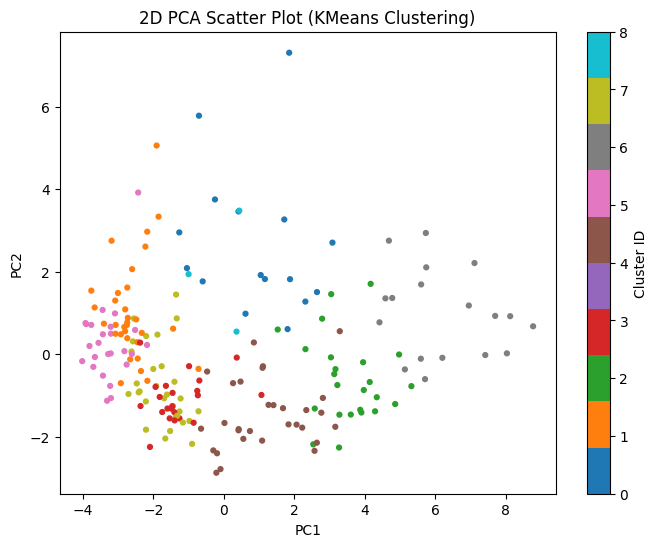

In [174]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Apply PCA on your feature data
pca = PCA(n_components=2)
pca_result = pca.fit_transform(test_data)

plt.figure(figsize=(8, 6))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=kmeans_assignment,       # cluster labels determine colors
    cmap='tab10',
    s=12
)

plt.title("2D PCA Scatter Plot (KMeans Clustering)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster ID")
plt.show()


In [175]:
## Experiment 2 – PathologyGAN + GMM(k=3)

In [176]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sknetwork.clustering import Louvain


In [177]:
#to create Adjacency matrix for  Louvain clustering
from sklearn.metrics import pairwise_distances 
from sklearn.preprocessing import MinMaxScaler


In [178]:
model = GaussianMixture(n_components=9, random_state=0)
gmm_assignment = model.fit_predict(test_data)


In [179]:
from scipy import sparse

louvain_model = Louvain(resolution = 0.3, modularity = 'newman', random_state = 0)
adjacency_matrix = sparse.csr_matrix(MinMaxScaler().fit_transform((test_data)))
louvain_assignment = louvain_model.fit_predict(adjacency_matrix)


In [180]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, v_measure_score
from sklearn.model_selection import KFold, train_test_split


In [181]:
gmm_counts = np.unique(gmm_assignment, return_counts=True)
louvain_counts = np.unique(louvain_assignment, return_counts = True)


In [182]:
print('GMM assignment counts')
pd.DataFrame({'Cluster Index': gmm_counts[0],
              'Number of members': gmm_counts[1]})

GMM assignment counts


,Cluster Index,Number of members
0,0,10
1,1,8
2,2,42
3,3,18
4,4,31
5,5,30
6,6,30
7,7,22
8,8,9


In [183]:
print('Louvain assignment counts')
pd.DataFrame({'Cluster Index': louvain_counts[0], 'Number of members':louvain_counts[1]}).set_index('Cluster Index')


Louvain assignment counts


,Number of members
Cluster Index,
0,200


In [184]:

gmm_silhouette = silhouette_score(test_data, gmm_assignment)

louvain_silhouette = None

gmm_v_measure = v_measure_score(test_label, gmm_assignment)
louvain_v_measure = v_measure_score(test_label, louvain_assignment)

pd.DataFrame({
    'Metrics': ['silhouette', 'v-measure'],
    'GMM':     [gmm_silhouette, gmm_v_measure],
    'Louvain': [louvain_silhouette, louvain_v_measure]
}).set_index('Metrics')


,GMM,Louvain
Metrics,,
silhouette,0.120292,NaN
v-measure,0.454113,0.0


In [185]:
def calculate_percent(sub_df, attrib):
    cnt = sub_df[attrib].count()
    output_sub_df = sub_df.groupby(attrib).count()
    return (output_sub_df/cnt)


C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\3873854115.py:2: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\3873854115.py:16: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\3873854115.py:27: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



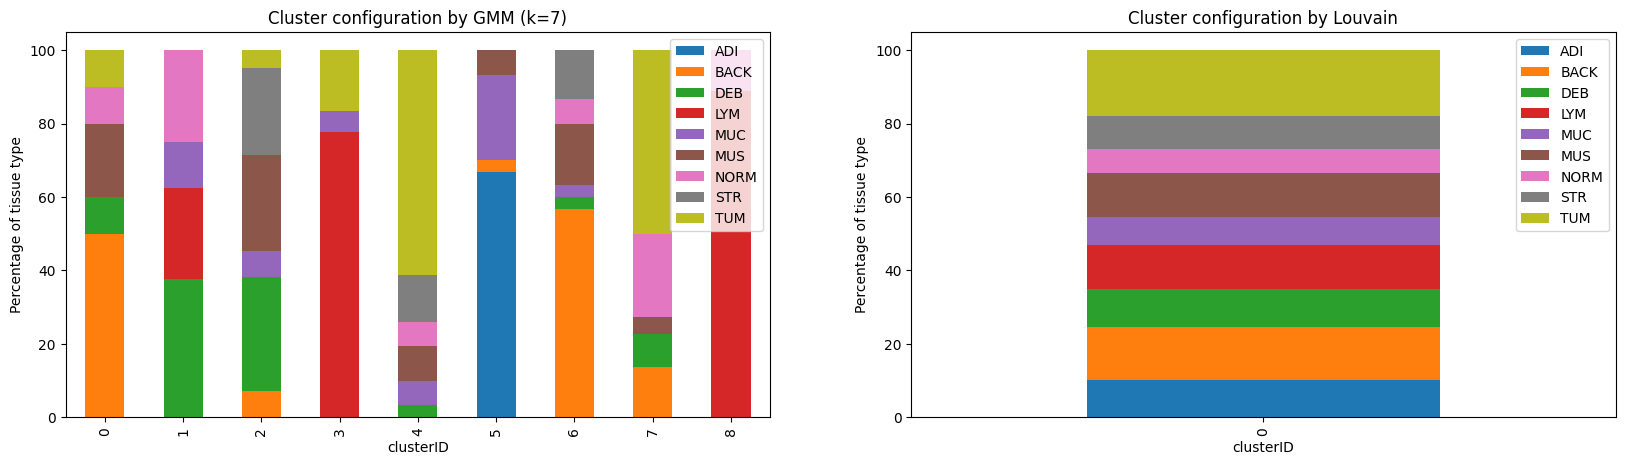

In [186]:
resulted_cluster_df = pd.DataFrame({'clusterID': gmm_assignment, 'type': test_label})
label_proportion_df = resulted_cluster_df.groupby(['clusterID']).apply(lambda x: calculate_percent(x,'type')).rename(columns={'clusterID':'type_occurrence_percentage'}).reset_index()
pivoted_label_proportion_df = pd.pivot_table(label_proportion_df, index = 'clusterID', columns = 'type', values = 'type_occurrence_percentage')


f, axes = plt.subplots(1, 2, figsize=(20,5))
number_of_tile_df = resulted_cluster_df.groupby('clusterID')['type'].count().reset_index().rename(columns={'type':'number_of_tile'})
df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df*100).loc[df_idx].plot.bar(stacked=True, ax = axes[0] )

axes[0].set_ylabel('Percentage of tissue type')
axes[0].legend(loc='upper right')
axes[0].set_title('Cluster configuration by GMM (k=7)')

resulted_cluster_df = pd.DataFrame({'clusterID': louvain_assignment, 'type': test_label})
label_proportion_df = resulted_cluster_df.groupby(['clusterID']).apply(lambda x: calculate_percent(x,'type')).rename(columns={'clusterID':'type_occurrence_percentage'}).reset_index()
pivoted_label_proportion_df = pd.pivot_table(label_proportion_df, index = 'clusterID', columns = 'type', values = 'type_occurrence_percentage')


number_of_tile_df = resulted_cluster_df.groupby('clusterID')['type'].count().reset_index().rename(columns={'type':'number_of_tile'})
df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df*100).loc[df_idx].plot.bar(stacked=True, ax = axes[1] )

axes[1].set_ylabel('Percentage of tissue type')
axes[1].legend(loc='upper right')
axes[1].set_title('Cluster configuration by Louvain')
f.show()


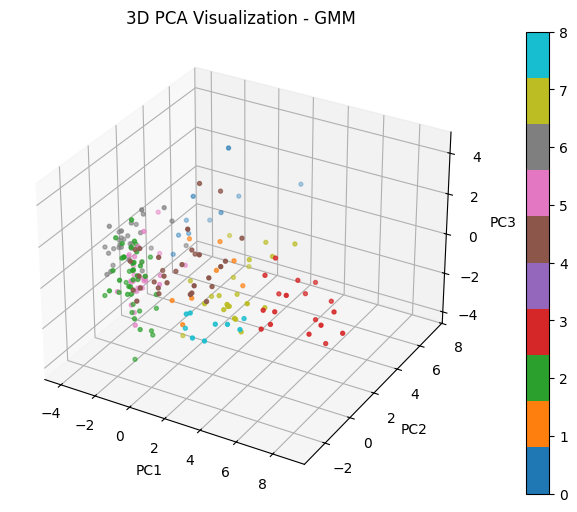

In [187]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Perform PCA with 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(test_data)

# Plot 3D PCA
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    pca_result[:, 2],
    c=gmm_assignment,   # or louvain_assignment
    cmap='tab10',
    s=8
)

ax.set_title("3D PCA Visualization - GMM")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.colorbar(scatter)
plt.show()


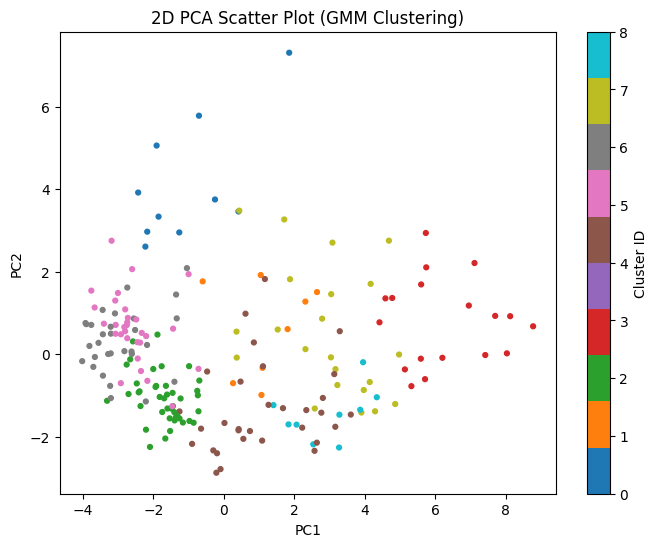

In [188]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Apply PCA on your feature data
pca = PCA(n_components=2)
pca_result = pca.fit_transform(test_data)

plt.figure(figsize=(8, 6))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=gmm_assignment,       # cluster labels determine colors
    cmap='tab10',
    s=12
)

plt.title("2D PCA Scatter Plot (GMM Clustering)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster ID")
plt.show()


In [189]:
print(kmeans_assignment[:20])
print(gmm_assignment[:20])


[5 0 1 6 7 7 5 1 7 0 2 4 4 7 7 7 5 2 4 6]
[6 0 5 3 2 6 6 5 4 0 7 8 4 2 2 2 2 3 4 3]


Agglomerative assignment counts


,Number of members
Cluster Index,
0,32
1,7
2,28
3,27
4,30
5,18
6,10
7,21
8,27



Louvain assignment counts


,Number of members
Cluster Index,
0,200



Evaluation metrics (Agglomerative vs Louvain)


,Agglomerative,Louvain
Metrics,,
silhouette,0.123925,NaN
v-measure,0.466162,0.0


C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\2082916261.py:67: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\2082916261.py:102: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



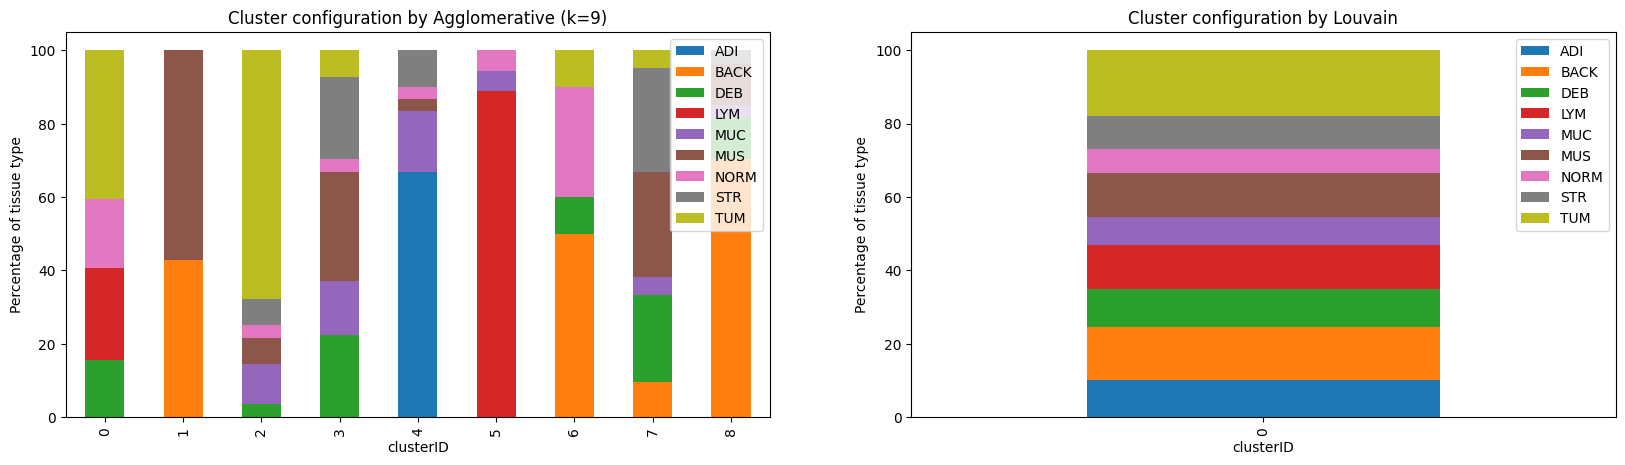

In [190]:
# === Experiment 3 – PathologyGAN + Agglomerative(k=3) ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sknetwork.clustering import Louvain

from sklearn.metrics import pairwise_distances, silhouette_score, v_measure_score
from sklearn.preprocessing import MinMaxScaler
from scipy import sparse

agg_model = AgglomerativeClustering(n_clusters=9)
agg_assignment = agg_model.fit_predict(test_data)

dist_matrix = pairwise_distances(test_data)
scaler = MinMaxScaler()
dist_norm = scaler.fit_transform(dist_matrix)
sim_matrix = 1 - dist_norm
adjacency_matrix = sparse.csr_matrix(sim_matrix)

louvain_model = Louvain(resolution=0.3, modularity='newman', random_state=0)
louvain_assignment = louvain_model.fit_predict(adjacency_matrix)

agg_counts = np.unique(agg_assignment, return_counts=True)
louvain_counts = np.unique(louvain_assignment, return_counts=True)

print("Agglomerative assignment counts")
display(pd.DataFrame({
    'Cluster Index': agg_counts[0],
    'Number of members': agg_counts[1]
}).set_index('Cluster Index'))

print("\nLouvain assignment counts")
display(pd.DataFrame({
    'Cluster Index': louvain_counts[0],
    'Number of members': louvain_counts[1]
}).set_index('Cluster Index'))

agg_silhouette = silhouette_score(test_data, agg_assignment)
louvain_silhouette = None

agg_v_measure = v_measure_score(test_label, agg_assignment)
louvain_v_measure = v_measure_score(test_label, louvain_assignment)

metrics_df = pd.DataFrame({
    'Metrics': ['silhouette', 'v-measure'],
    'Agglomerative': [agg_silhouette, agg_v_measure],
    'Louvain': [louvain_silhouette, louvain_v_measure]
}).set_index('Metrics')

print("\nEvaluation metrics (Agglomerative vs Louvain)")
display(metrics_df)

def calculate_percent(sub_df, attrib):
    cnt = sub_df[attrib].count()
    output_sub_df = sub_df.groupby(attrib).count()
    return (output_sub_df / cnt)

# --- Agglomerative ---
resulted_cluster_df = pd.DataFrame({'clusterID': agg_assignment,
                                    'type': test_label})
label_proportion_df = (
    resulted_cluster_df
    .groupby(['clusterID'])
    .apply(lambda x: calculate_percent(x, 'type'))
    .rename(columns={'clusterID': 'type_occurrence_count'})
    .reset_index()
)
pivoted_label_proportion_df = pd.pivot_table(
    label_proportion_df,
    index='clusterID',
    columns='type',
    values='type_occurrence_count'
)

f, axes = plt.subplots(1, 2, figsize=(20, 5))

number_of_tile_df = (
    resulted_cluster_df
    .groupby('clusterID')['type']
    .count()
    .reset_index()
    .rename(columns={'type': 'number_of_tile'})
)
df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df * 100).loc[df_idx].plot.bar(
    stacked=True, ax=axes[0]
)

axes[0].set_ylabel('Percentage of tissue type')
axes[0].legend(loc='upper right')
axes[0].set_title('Cluster configuration by Agglomerative (k=9)')

# --- Louvain ---
resulted_cluster_df = pd.DataFrame({'clusterID': louvain_assignment,
                                    'type': test_label})
label_proportion_df = (
    resulted_cluster_df
    .groupby(['clusterID'])
    .apply(lambda x: calculate_percent(x, 'type'))
    .rename(columns={'clusterID': 'type_occurrence_count'})
    .reset_index()
)
pivoted_label_proportion_df = pd.pivot_table(
    label_proportion_df,
    index='clusterID',
    columns='type',
    values='type_occurrence_count'
)

number_of_tile_df = (
    resulted_cluster_df
    .groupby('clusterID')['type']
    .count()
    .reset_index()
    .rename(columns={'type': 'number_of_tile'})
)
df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df * 100).loc[df_idx].plot.bar(
    stacked=True, ax=axes[1]
)

axes[1].set_ylabel('Percentage of tissue type')
axes[1].legend(loc='upper right')
axes[1].set_title('Cluster configuration by Louvain')

plt.show()


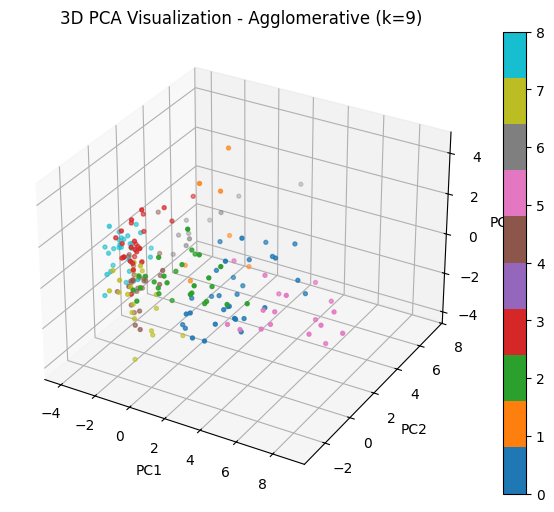

In [191]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Perform PCA with 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(test_data)

# Plot 3D PCA
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    pca_result[:, 2],
    c=agg_assignment,   # or louvain_assignment
    cmap='tab10',
    s=8
)

ax.set_title("3D PCA Visualization - Agglomerative (k=9)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.colorbar(scatter)
plt.show()


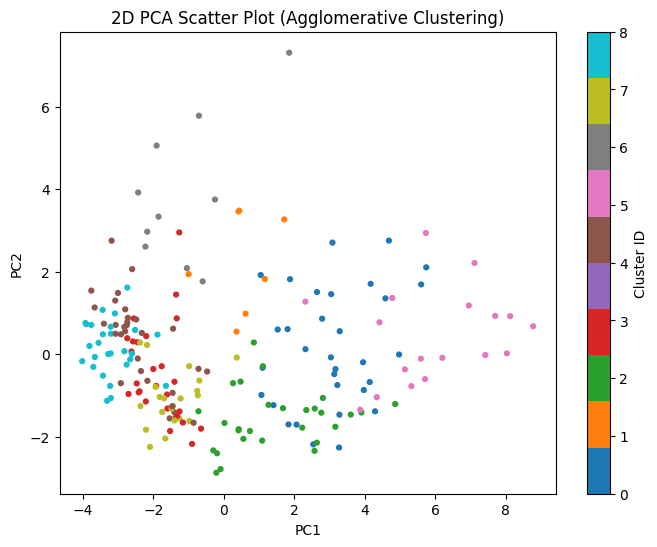

In [192]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Apply PCA on your feature data
pca = PCA(n_components=2)
pca_result = pca.fit_transform(test_data)

# Step 2: Plot PCA coloured by Agglomerative clusters
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=agg_assignment,       # cluster labels determine colors
    cmap='tab10',
    s=12
)

plt.title("2D PCA Scatter Plot (Agglomerative Clustering)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster ID")
plt.show()


ResNet50 + KMeans assignment counts


c:\Users\BehShuAo\anaconda3\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



,Number of members
Cluster Index,
0,13
1,28
2,18
3,21
4,20
5,25
6,38
7,17
8,20



Louvain assignment counts (ResNet50)


,Number of members
Cluster Index,
0,200



Evaluation metrics (ResNet50: KMeans vs Louvain)


,KMeans,Louvain
Metrics,,
silhouette,0.157681,NaN
v-measure,0.622908,0.0


C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\3492135334.py:73: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\3492135334.py:101: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



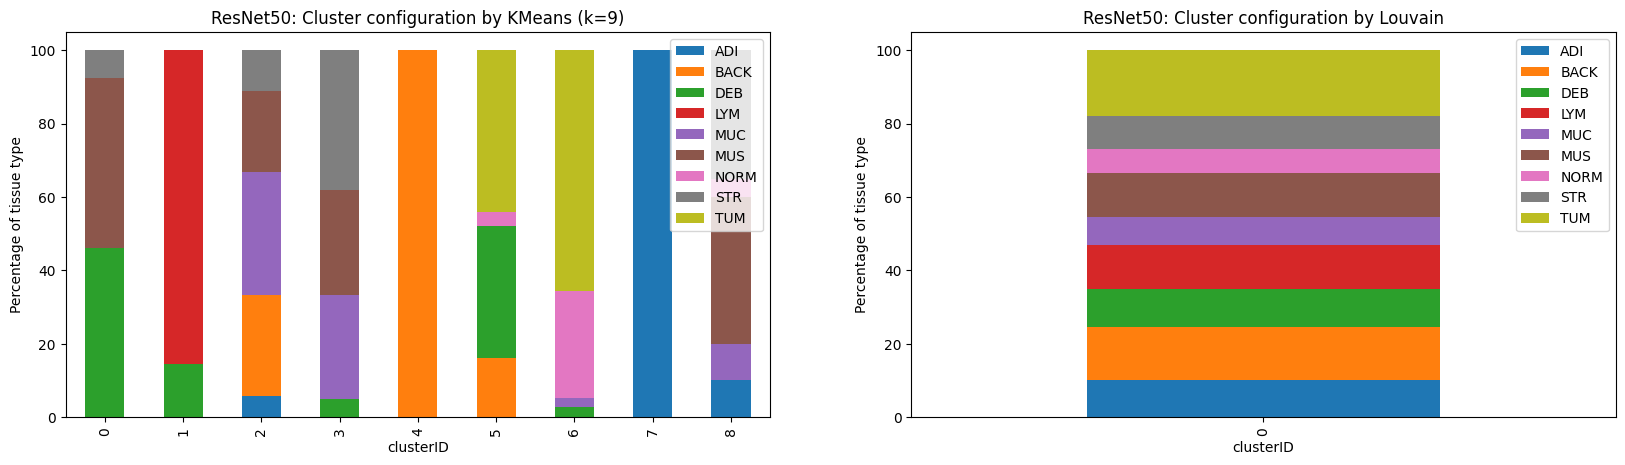

In [193]:
# === Experiment R1 – ResNet50 + KMeans(k=3) ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sknetwork.clustering import Louvain

from sklearn.metrics import pairwise_distances, silhouette_score, v_measure_score
from sklearn.preprocessing import MinMaxScaler
from scipy import sparse

test_data = resnet50_pca_feature[selected_index]
test_label = labels[selected_index]

# KMeans
kmeans_model = KMeans(n_clusters=9, random_state=0)
kmeans_assignment = kmeans_model.fit_predict(test_data)

# Louvain
dist_matrix = pairwise_distances(test_data)
scaler = MinMaxScaler()
dist_norm = scaler.fit_transform(dist_matrix)
sim_matrix = 1 - dist_norm
adjacency_matrix = sparse.csr_matrix(sim_matrix)

louvain_model = Louvain(resolution=0.3, modularity='newman', random_state=0)
louvain_assignment = louvain_model.fit_predict(adjacency_matrix)

# assignment counts
kmeans_counts = np.unique(kmeans_assignment, return_counts=True)
louvain_counts = np.unique(louvain_assignment, return_counts=True)

print("ResNet50 + KMeans assignment counts")
display(pd.DataFrame({
    'Cluster Index': kmeans_counts[0],
    'Number of members': kmeans_counts[1]
}).set_index('Cluster Index'))

print("\nLouvain assignment counts (ResNet50)")
display(pd.DataFrame({
    'Cluster Index': louvain_counts[0],
    'Number of members': louvain_counts[1]
}).set_index('Cluster Index'))

kmeans_silhouette = silhouette_score(test_data, kmeans_assignment)
louvain_silhouette = None

kmeans_v_measure = v_measure_score(test_label, kmeans_assignment)
louvain_v_measure = v_measure_score(test_label, louvain_assignment)

metrics_df = pd.DataFrame({
    'Metrics': ['silhouette', 'v-measure'],
    'KMeans':  [kmeans_silhouette, kmeans_v_measure],
    'Louvain': [louvain_silhouette, louvain_v_measure]
}).set_index('Metrics')

print("\nEvaluation metrics (ResNet50: KMeans vs Louvain)")
display(metrics_df)

def calculate_percent(sub_df, attrib):
    cnt = sub_df[attrib].count()
    output_sub_df = sub_df.groupby(attrib).count()
    return (output_sub_df / cnt)

# --- KMeans ---
resulted_cluster_df = pd.DataFrame({'clusterID': kmeans_assignment,
                                    'type': test_label})
label_proportion_df = (
    resulted_cluster_df
    .groupby(['clusterID'])
    .apply(lambda x: calculate_percent(x, 'type'))
    .rename(columns={'clusterID': 'type_occurrence_count'})
    .reset_index()
)
pivoted_label_proportion_df = pd.pivot_table(
    label_proportion_df,
    index='clusterID',
    columns='type',
    values='type_occurrence_count'
)

f, axes = plt.subplots(1, 2, figsize=(20, 5))

df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df * 100).loc[df_idx].plot.bar(
    stacked=True, ax=axes[0]
)

axes[0].set_ylabel('Percentage of tissue type')
axes[0].legend(loc='upper right')
axes[0].set_title('ResNet50: Cluster configuration by KMeans (k=9)')

# --- Louvain ---
resulted_cluster_df = pd.DataFrame({'clusterID': louvain_assignment,
                                    'type': test_label})
label_proportion_df = (
    resulted_cluster_df
    .groupby(['clusterID'])
    .apply(lambda x: calculate_percent(x, 'type'))
    .rename(columns={'clusterID': 'type_occurrence_count'})
    .reset_index()
)
pivoted_label_proportion_df = pd.pivot_table(
    label_proportion_df,
    index='clusterID',
    columns='type',
    values='type_occurrence_count'
)

df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df * 100).loc[df_idx].plot.bar(
    stacked=True, ax=axes[1]
)

axes[1].set_ylabel('Percentage of tissue type')
axes[1].legend(loc='upper right')
axes[1].set_title('ResNet50: Cluster configuration by Louvain')

plt.show()


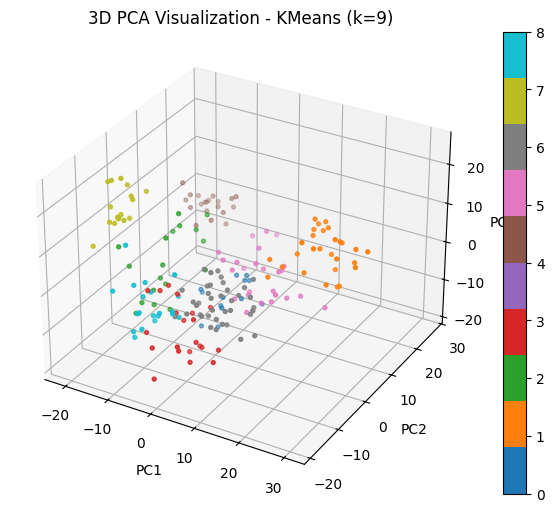

In [194]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Perform PCA with 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(test_data)

# Plot 3D PCA
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    pca_result[:, 2],
    c=kmeans_assignment,   # or louvain_assignment
    cmap='tab10',
    s=8
)

ax.set_title("3D PCA Visualization - KMeans (k=9)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.colorbar(scatter)
plt.show()

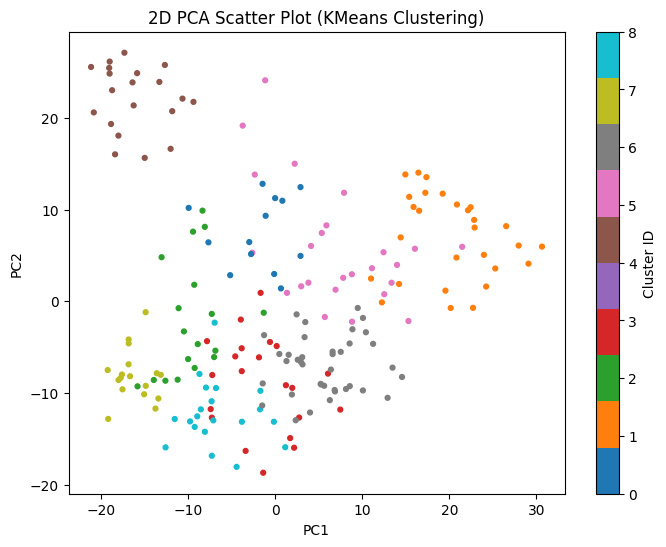

In [195]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Apply PCA on your feature data
pca = PCA(n_components=2)
pca_result = pca.fit_transform(test_data)

# Step 2: Plot PCA coloured by Agglomerative clusters
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=kmeans_assignment,       # cluster labels determine colors
    cmap='tab10',
    s=12
)

plt.title("2D PCA Scatter Plot (KMeans Clustering)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster ID")
plt.show()


ResNet50 + GMM assignment counts


,Number of members
Cluster Index,
0,29
1,27
2,54
3,21
4,24
5,27
6,18



Louvain assignment counts (ResNet50)


,Number of members
Cluster Index,
0,200



Evaluation metrics (ResNet50: GMM vs Louvain)


,GMM,Louvain
Metrics,,
silhouette,0.163610,NaN
v-measure,0.644713,0.0


C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\2746443049.py:75: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\2746443049.py:103: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



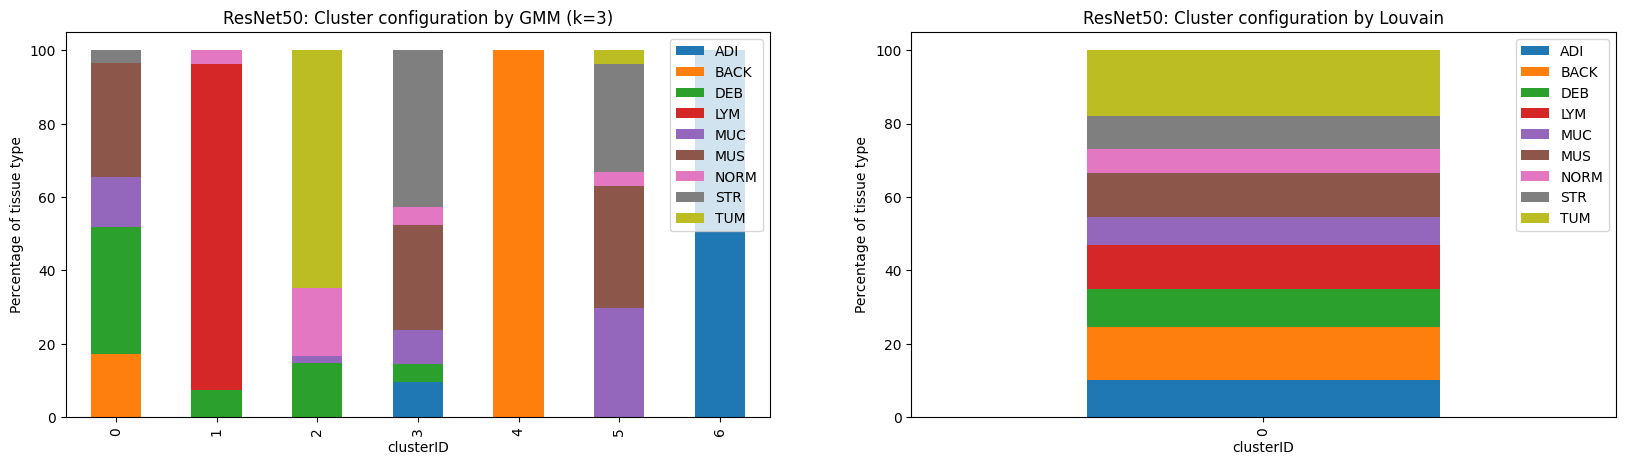

In [196]:
# === Experiment R2 – ResNet50 + GMM(k=3) ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sknetwork.clustering import Louvain

from sklearn.metrics import pairwise_distances, silhouette_score, v_measure_score
from sklearn.preprocessing import MinMaxScaler
from scipy import sparse

#  ResNet50
test_data = resnet50_pca_feature[selected_index]
test_label = labels[selected_index]

# GMM
gmm_model = GaussianMixture(n_components=7, random_state=0)
gmm_assignment = gmm_model.fit_predict(test_data)

# Louvain
dist_matrix = pairwise_distances(test_data)
scaler = MinMaxScaler()
dist_norm = scaler.fit_transform(dist_matrix)
sim_matrix = 1 - dist_norm
adjacency_matrix = sparse.csr_matrix(sim_matrix)

louvain_model = Louvain(resolution=0.3, modularity='newman', random_state=0)
louvain_assignment = louvain_model.fit_predict(adjacency_matrix)

# assignment counts
gmm_counts = np.unique(gmm_assignment, return_counts=True)
louvain_counts = np.unique(louvain_assignment, return_counts=True)

print("ResNet50 + GMM assignment counts")
display(pd.DataFrame({
    'Cluster Index': gmm_counts[0],
    'Number of members': gmm_counts[1]
}).set_index('Cluster Index'))

print("\nLouvain assignment counts (ResNet50)")
display(pd.DataFrame({
    'Cluster Index': louvain_counts[0],
    'Number of members': louvain_counts[1]
}).set_index('Cluster Index'))

gmm_silhouette = silhouette_score(test_data, gmm_assignment)
louvain_silhouette = None

gmm_v_measure = v_measure_score(test_label, gmm_assignment)
louvain_v_measure = v_measure_score(test_label, louvain_assignment)

metrics_df = pd.DataFrame({
    'Metrics': ['silhouette', 'v-measure'],
    'GMM':     [gmm_silhouette, gmm_v_measure],
    'Louvain': [louvain_silhouette, louvain_v_measure]
}).set_index('Metrics')

print("\nEvaluation metrics (ResNet50: GMM vs Louvain)")
display(metrics_df)

def calculate_percent(sub_df, attrib):
    cnt = sub_df[attrib].count()
    output_sub_df = sub_df.groupby(attrib).count()
    return (output_sub_df / cnt)


# --- GMM ---
resulted_cluster_df = pd.DataFrame({'clusterID': gmm_assignment,
                                    'type': test_label})
label_proportion_df = (
    resulted_cluster_df
    .groupby(['clusterID'])
    .apply(lambda x: calculate_percent(x, 'type'))
    .rename(columns={'clusterID': 'type_occurrence_count'})
    .reset_index()
)
pivoted_label_proportion_df = pd.pivot_table(
    label_proportion_df,
    index='clusterID',
    columns='type',
    values='type_occurrence_count'
)

f, axes = plt.subplots(1, 2, figsize=(20, 5))

df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df * 100).loc[df_idx].plot.bar(
    stacked=True, ax=axes[0]
)

axes[0].set_ylabel('Percentage of tissue type')
axes[0].legend(loc='upper right')
axes[0].set_title('ResNet50: Cluster configuration by GMM (k=3)')

# --- Louvain ---
resulted_cluster_df = pd.DataFrame({'clusterID': louvain_assignment,
                                    'type': test_label})
label_proportion_df = (
    resulted_cluster_df
    .groupby(['clusterID'])
    .apply(lambda x: calculate_percent(x, 'type'))
    .rename(columns={'clusterID': 'type_occurrence_count'})
    .reset_index()
)
pivoted_label_proportion_df = pd.pivot_table(
    label_proportion_df,
    index='clusterID',
    columns='type',
    values='type_occurrence_count'
)

df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df * 100).loc[df_idx].plot.bar(
    stacked=True, ax=axes[1]
)

axes[1].set_ylabel('Percentage of tissue type')
axes[1].legend(loc='upper right')
axes[1].set_title('ResNet50: Cluster configuration by Louvain')

plt.show()


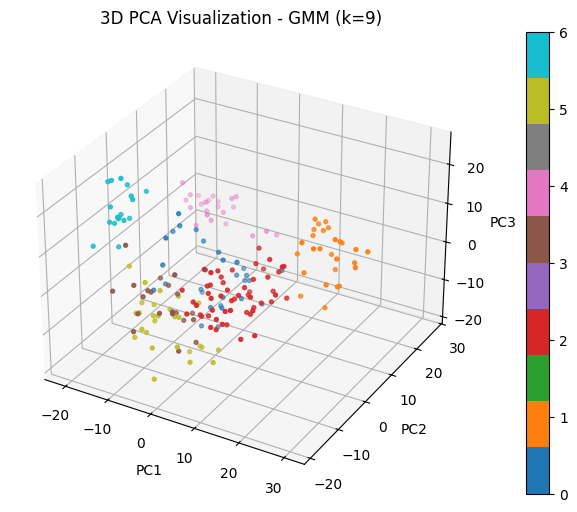

In [197]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Perform PCA with 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(test_data)

# Plot 3D PCA
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    pca_result[:, 2],
    c=gmm_assignment,   # or louvain_assignment
    cmap='tab10',
    s=8
)

ax.set_title("3D PCA Visualization - GMM (k=9)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.colorbar(scatter)
plt.show()


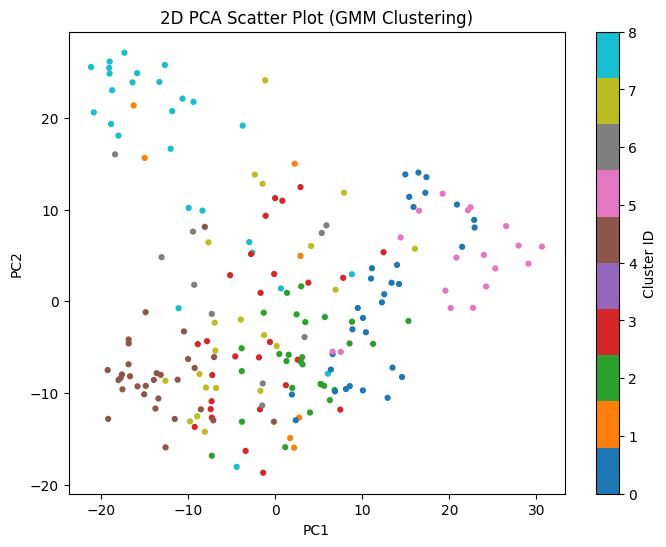

In [198]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Apply PCA on your feature data
pca = PCA(n_components=2)
pca_result = pca.fit_transform(test_data)

# Step 2: Plot PCA coloured by Agglomerative clusters
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=agg_assignment,       # cluster labels determine colors
    cmap='tab10',
    s=12
)

plt.title("2D PCA Scatter Plot (GMM Clustering)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster ID")
plt.show()


ResNet50 + Agglomerative assignment counts


,Number of members
Cluster Index,
0,25
1,39
2,25
3,16
4,21
5,20
6,21
7,18
8,15



Louvain assignment counts (ResNet50)


,Number of members
Cluster Index,
0,200



Evaluation metrics (ResNet50: Agglomerative vs Louvain)


,Agglomerative,Louvain
Metrics,,
silhouette,0.157886,NaN
v-measure,0.596463,0.0


C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\534892229.py:73: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\534892229.py:101: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



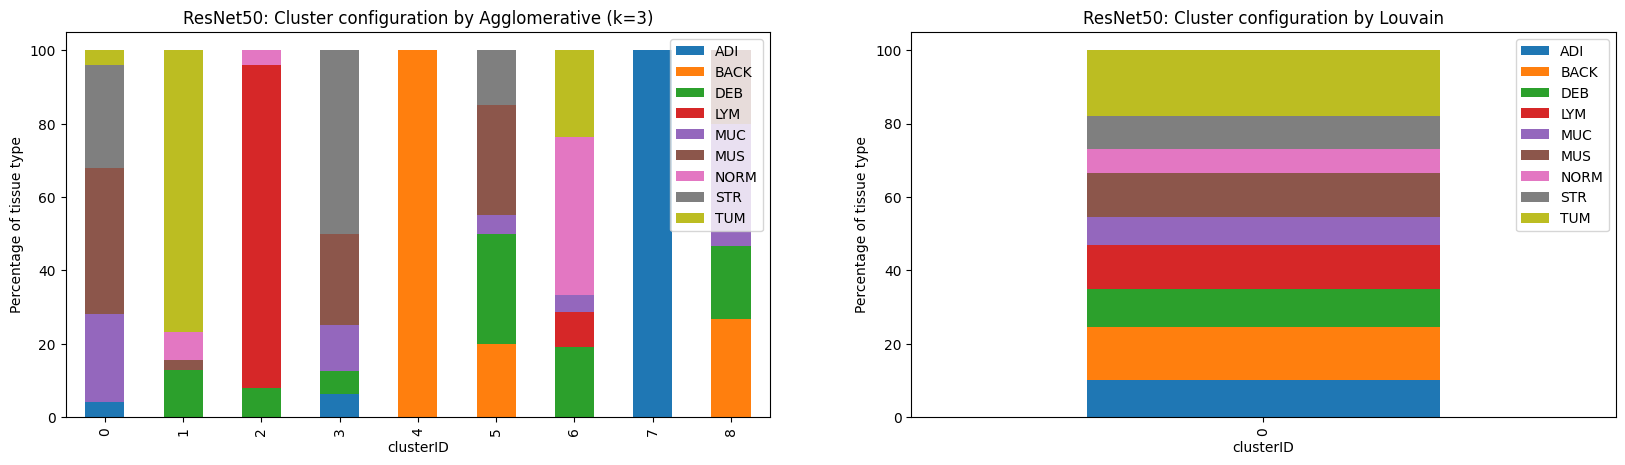

In [199]:
# === Experiment R3 – ResNet50 + Agglomerative(k=3) ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sknetwork.clustering import Louvain

from sklearn.metrics import pairwise_distances, silhouette_score, v_measure_score
from sklearn.preprocessing import MinMaxScaler
from scipy import sparse

# ResNet50  & label
test_data = resnet50_pca_feature[selected_index]
test_label = labels[selected_index]

# Agglomerative
agg_model = AgglomerativeClustering(n_clusters=9)
agg_assignment = agg_model.fit_predict(test_data)

# Louvain
dist_matrix = pairwise_distances(test_data)
scaler = MinMaxScaler()
dist_norm = scaler.fit_transform(dist_matrix)
sim_matrix = 1 - dist_norm
adjacency_matrix = sparse.csr_matrix(sim_matrix)

louvain_model = Louvain(resolution=0.7, modularity='newman', random_state=0)
louvain_assignment = louvain_model.fit_predict(adjacency_matrix)

# assignment counts
agg_counts = np.unique(agg_assignment, return_counts=True)
louvain_counts = np.unique(louvain_assignment, return_counts=True)

print("ResNet50 + Agglomerative assignment counts")
display(pd.DataFrame({
    'Cluster Index': agg_counts[0],
    'Number of members': agg_counts[1]
}).set_index('Cluster Index'))

print("\nLouvain assignment counts (ResNet50)")
display(pd.DataFrame({
    'Cluster Index': louvain_counts[0],
    'Number of members': louvain_counts[1]
}).set_index('Cluster Index'))

agg_silhouette = silhouette_score(test_data, agg_assignment)
louvain_silhouette = None

agg_v_measure = v_measure_score(test_label, agg_assignment)
louvain_v_measure = v_measure_score(test_label, louvain_assignment)

metrics_df = pd.DataFrame({
    'Metrics': ['silhouette', 'v-measure'],
    'Agglomerative': [agg_silhouette, agg_v_measure],
    'Louvain':      [louvain_silhouette, louvain_v_measure]
}).set_index('Metrics')

print("\nEvaluation metrics (ResNet50: Agglomerative vs Louvain)")
display(metrics_df)

def calculate_percent(sub_df, attrib):
    cnt = sub_df[attrib].count()
    output_sub_df = sub_df.groupby(attrib).count()
    return (output_sub_df / cnt)
# --- Agglomerative ---
resulted_cluster_df = pd.DataFrame({'clusterID': agg_assignment,
                                    'type': test_label})
label_proportion_df = (
    resulted_cluster_df
    .groupby(['clusterID'])
    .apply(lambda x: calculate_percent(x, 'type'))
    .rename(columns={'clusterID': 'type_occurrence_count'})
    .reset_index()
)
pivoted_label_proportion_df = pd.pivot_table(
    label_proportion_df,
    index='clusterID',
    columns='type',
    values='type_occurrence_count'
)

f, axes = plt.subplots(1, 2, figsize=(20, 5))

df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df * 100).loc[df_idx].plot.bar(
    stacked=True, ax=axes[0]
)

axes[0].set_ylabel('Percentage of tissue type')
axes[0].legend(loc='upper right')
axes[0].set_title('ResNet50: Cluster configuration by Agglomerative (k=3)')

# --- Louvain ---
resulted_cluster_df = pd.DataFrame({'clusterID': louvain_assignment,
                                    'type': test_label})
label_proportion_df = (
    resulted_cluster_df
    .groupby(['clusterID'])
    .apply(lambda x: calculate_percent(x, 'type'))
    .rename(columns={'clusterID': 'type_occurrence_count'})
    .reset_index()
)
pivoted_label_proportion_df = pd.pivot_table(
    label_proportion_df,
    index='clusterID',
    columns='type',
    values='type_occurrence_count'
)

df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df * 100).loc[df_idx].plot.bar(
    stacked=True, ax=axes[1]
)

axes[1].set_ylabel('Percentage of tissue type')
axes[1].legend(loc='upper right')
axes[1].set_title('ResNet50: Cluster configuration by Louvain')

plt.show()


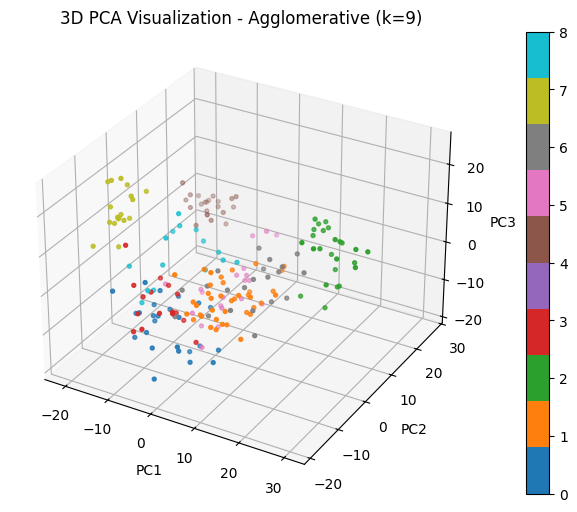

In [200]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Perform PCA with 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(test_data)

# Plot 3D PCA
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    pca_result[:, 2],
    c=agg_assignment,   # or louvain_assignment
    cmap='tab10',
    s=8
)

ax.set_title("3D PCA Visualization - Agglomerative (k=9)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.colorbar(scatter)
plt.show()


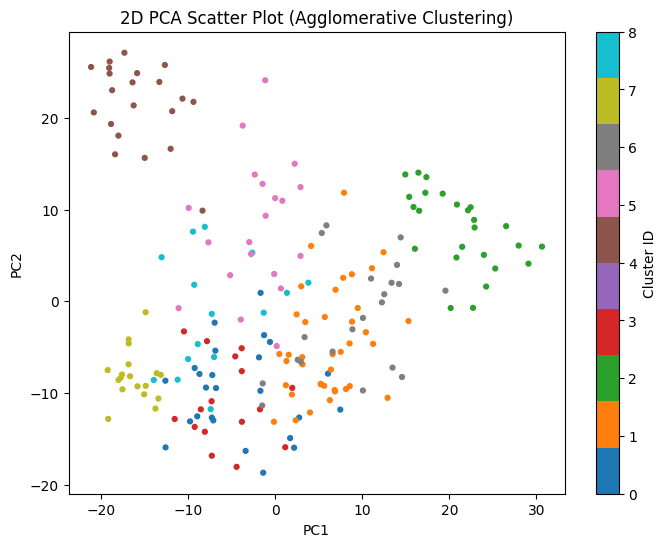

In [201]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Apply PCA on your feature data
pca = PCA(n_components=2)
pca_result = pca.fit_transform(test_data)

# Step 2: Plot PCA coloured by Agglomerative clusters
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=agg_assignment,       # cluster labels determine colors
    cmap='tab10',
    s=12
)

plt.title("2D PCA Scatter Plot (Agglomerative Clustering)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster ID")
plt.show()


VGG16 + KMeans assignment counts


c:\Users\BehShuAo\anaconda3\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



,Number of members
Cluster Index,
0,27
1,26
2,14
3,14
4,20
5,16
6,25
7,18
8,40



Evaluation metrics (VGG16: KMeans)


,KMeans
Metrics,
silhouette,0.133950
v-measure,0.597476


C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\3683989618.py:51: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



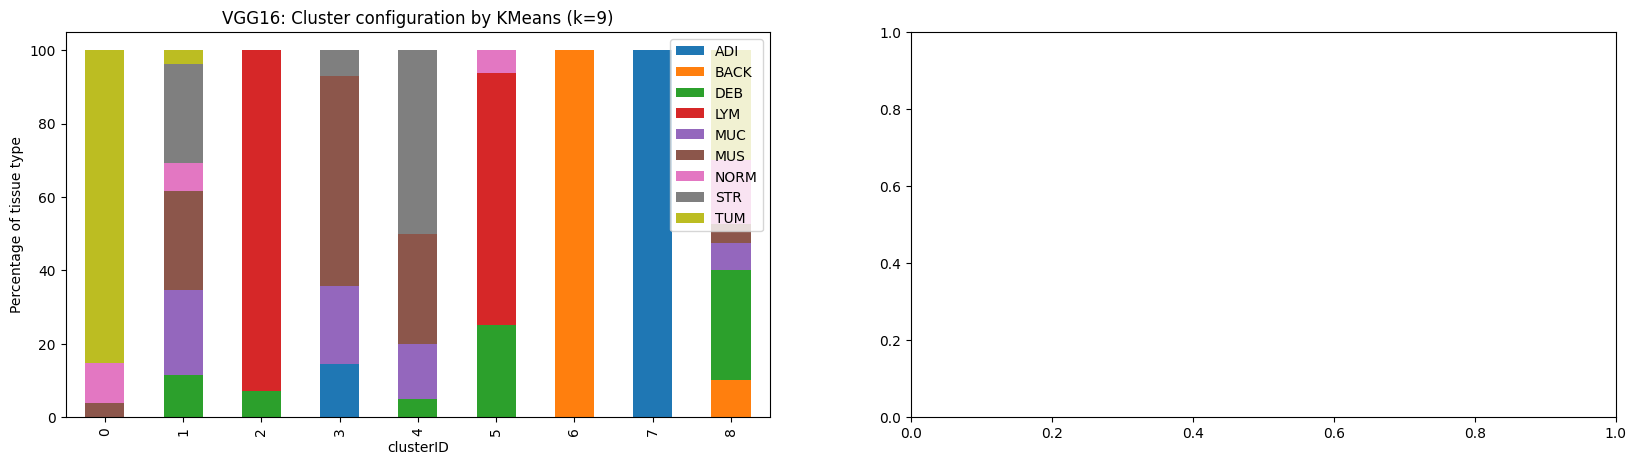

In [208]:
# === Experiment V1 – VGG16 + PCA + KMeans(k=3) ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sknetwork.clustering import Louvain

from sklearn.metrics import pairwise_distances, silhouette_score, v_measure_score
from sklearn.preprocessing import MinMaxScaler
from scipy import sparse

test_data = vgg16_pca_feature[selected_index]
test_label = labels[selected_index]

# KMeans
kmeans_model = KMeans(n_clusters=9, random_state=0)
kmeans_assignment = kmeans_model.fit_predict(test_data)

# assignment counts
kmeans_counts = np.unique(kmeans_assignment, return_counts=True)

print("VGG16 + KMeans assignment counts")
display(pd.DataFrame({
    'Cluster Index': kmeans_counts[0],
    'Number of members': kmeans_counts[1]
}).set_index('Cluster Index'))



kmeans_silhouette = silhouette_score(test_data, kmeans_assignment)

kmeans_v_measure = v_measure_score(test_label, kmeans_assignment)

metrics_df = pd.DataFrame({
    'Metrics': ['silhouette', 'v-measure'],
    'KMeans':  [kmeans_silhouette, kmeans_v_measure],
}).set_index('Metrics')

print("\nEvaluation metrics (VGG16: KMeans)")
display(metrics_df)


# --- KMeans ---
resulted_cluster_df = pd.DataFrame({'clusterID': kmeans_assignment,
                                    'type': test_label})
label_proportion_df = (
    resulted_cluster_df
    .groupby(['clusterID'])
    .apply(lambda x: calculate_percent(x, 'type'))
    .rename(columns={'clusterID': 'type_occurrence_count'})
    .reset_index()
)
pivoted_label_proportion_df = pd.pivot_table(
    label_proportion_df,
    index='clusterID',
    columns='type',
    values='type_occurrence_count'
)

f, axes = plt.subplots(1, 2, figsize=(20, 5))

df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df * 100).loc[df_idx].plot.bar(
    stacked=True, ax=axes[0]
)

axes[0].set_ylabel('Percentage of tissue type')
axes[0].legend(loc='upper right')
axes[0].set_title('VGG16: Cluster configuration by KMeans (k=9)')

plt.show()


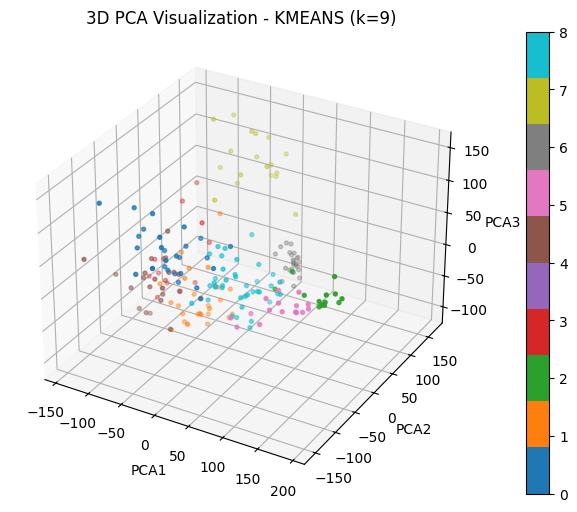

In [209]:
# Perform PCA with 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(test_data)

# Plot 3D PCA
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    pca_result[:, 2],
    c=kmeans_assignment,   # or louvain_assignment
    cmap='tab10',
    s=8
)

ax.set_title("3D PCA Visualization - KMEANS (k=9)")
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
plt.colorbar(scatter)
plt.show()

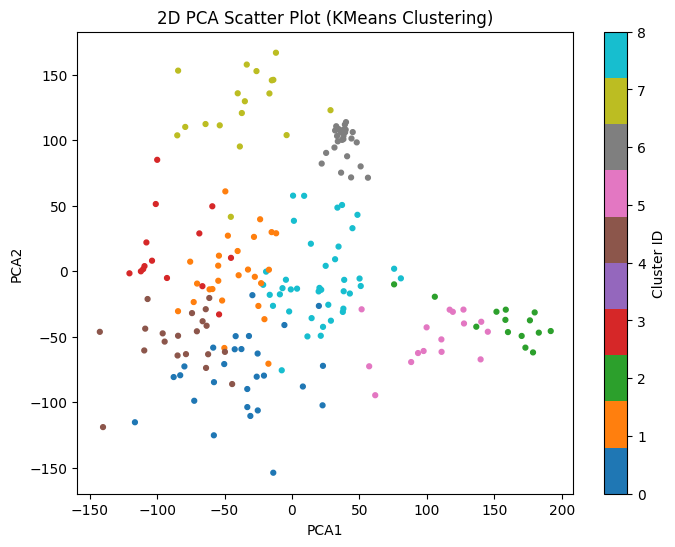

In [210]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(test_data)

# Step 2: Plot PCA coloured by Agglomerative clusters
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=kmeans_assignment,       # cluster labels determine colors
    cmap='tab10',
    s=12
)

plt.title("2D PCA Scatter Plot (KMeans Clustering)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.colorbar(label="Cluster ID")
plt.show()

VGG16 + GMM assignment counts


,Number of members
Cluster Index,
0,21
1,36
2,31
3,13
4,20
5,13
6,36
7,24
8,6



Evaluation metrics (VGG16: GMM)


,GMM
Metrics,
silhouette,0.109892
v-measure,0.608019


C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\155657308.py:49: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



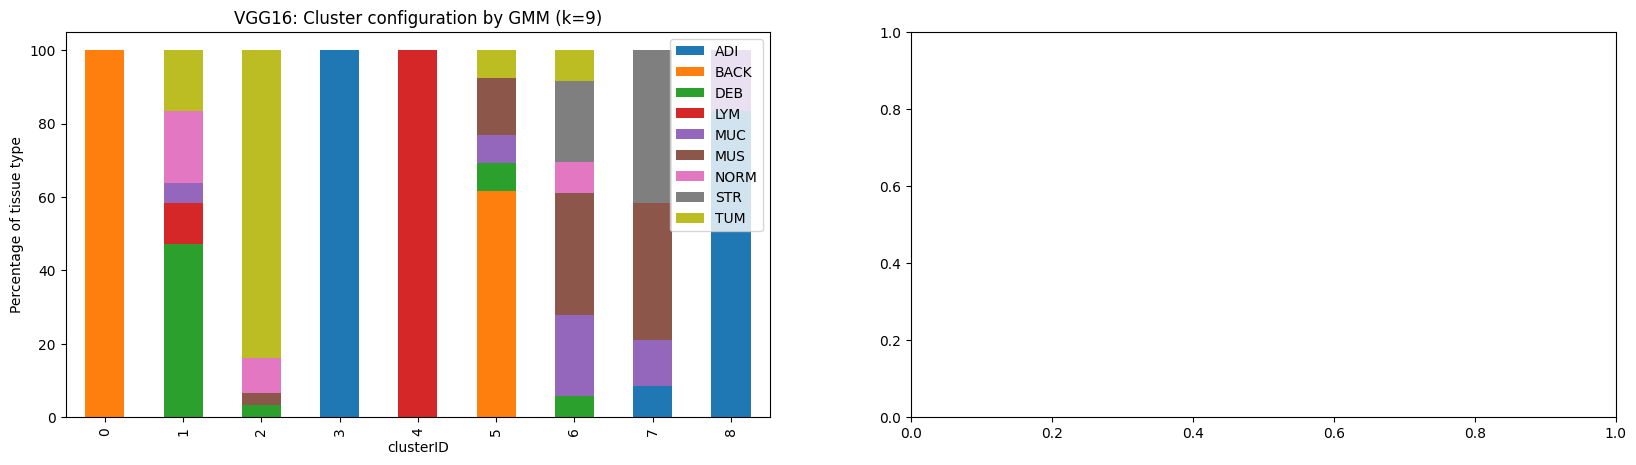

In [211]:
# === Experiment R2 – VGG16 + PCA +  GMM(k=3) ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sknetwork.clustering import Louvain

from sklearn.metrics import pairwise_distances, silhouette_score, v_measure_score
from sklearn.preprocessing import MinMaxScaler
from scipy import sparse

#  ResNet50
test_data = vgg16_pca_feature[selected_index]
test_label = labels[selected_index]

# GMM
gmm_model = GaussianMixture(n_components=9, random_state=0)
gmm_assignment = gmm_model.fit_predict(test_data)

# assignment counts
gmm_counts = np.unique(gmm_assignment, return_counts=True)

print("VGG16 + GMM assignment counts")
display(pd.DataFrame({
    'Cluster Index': gmm_counts[0],
    'Number of members': gmm_counts[1]
}).set_index('Cluster Index'))

gmm_silhouette = silhouette_score(test_data, gmm_assignment)

gmm_v_measure = v_measure_score(test_label, gmm_assignment)

metrics_df = pd.DataFrame({
    'Metrics': ['silhouette', 'v-measure'],
    'GMM':     [gmm_silhouette, gmm_v_measure],
}).set_index('Metrics')

print("\nEvaluation metrics (VGG16: GMM)")
display(metrics_df)

# --- GMM ---
resulted_cluster_df = pd.DataFrame({'clusterID': gmm_assignment,
                                    'type': test_label})
label_proportion_df = (
    resulted_cluster_df
    .groupby(['clusterID'])
    .apply(lambda x: calculate_percent(x, 'type'))
    .rename(columns={'clusterID': 'type_occurrence_count'})
    .reset_index()
)
pivoted_label_proportion_df = pd.pivot_table(
    label_proportion_df,
    index='clusterID',
    columns='type',
    values='type_occurrence_count'
)

f, axes = plt.subplots(1, 2, figsize=(20, 5))

df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df * 100).loc[df_idx].plot.bar(
    stacked=True, ax=axes[0]
)

axes[0].set_ylabel('Percentage of tissue type')
axes[0].legend(loc='upper right')
axes[0].set_title('VGG16: Cluster configuration by GMM (k=9)')



plt.show()


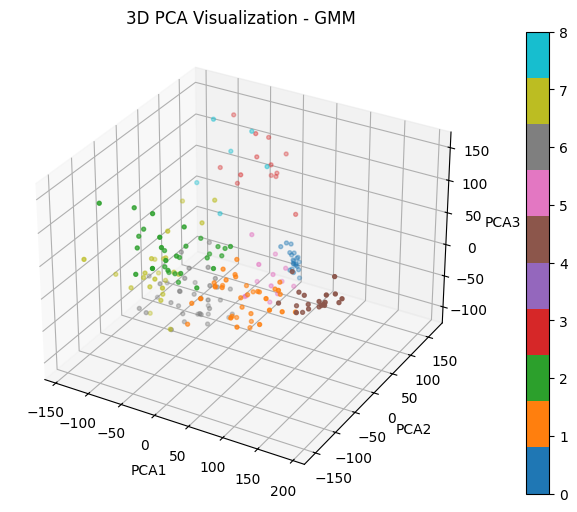

In [212]:
# Perform PCA with 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(test_data)

# Plot 3D PCA
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    pca_result[:, 2],
    c=gmm_assignment,   # or louvain_assignment
    cmap='tab10',
    s=8
)

ax.set_title("3D PCA Visualization - GMM")
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
plt.colorbar(scatter)
plt.show()

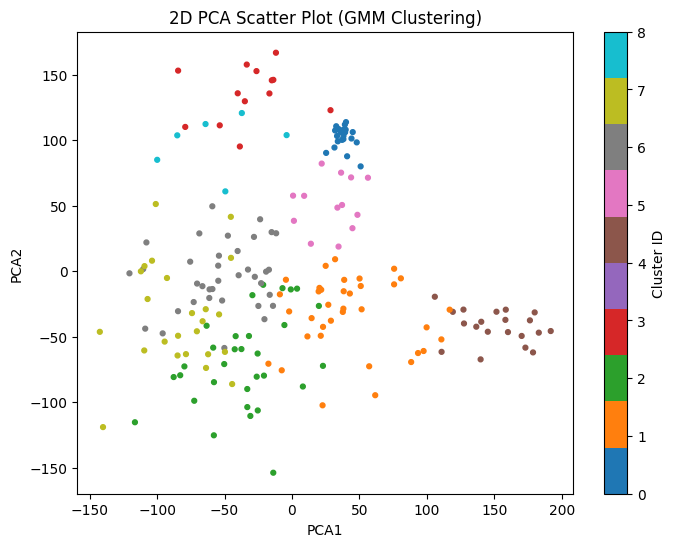

In [213]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(test_data)

# Step 2: Plot PCA coloured by Agglomerative clusters
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=gmm_assignment,       # cluster labels determine colors
    cmap='tab10',
    s=12
)

plt.title("2D PCA Scatter Plot (GMM Clustering)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.colorbar(label="Cluster ID")
plt.show()

VGG16 + Agglomerative assignment counts


,Number of members
Cluster Index,
0,34
1,21
2,23
3,20
4,26
5,12
6,33
7,23
8,8



Evaluation metrics (VGG16: Agglomerative)


,Agglomerative
Metrics,
silhouette,0.127045
v-measure,0.572278


C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\159050393.py:49: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



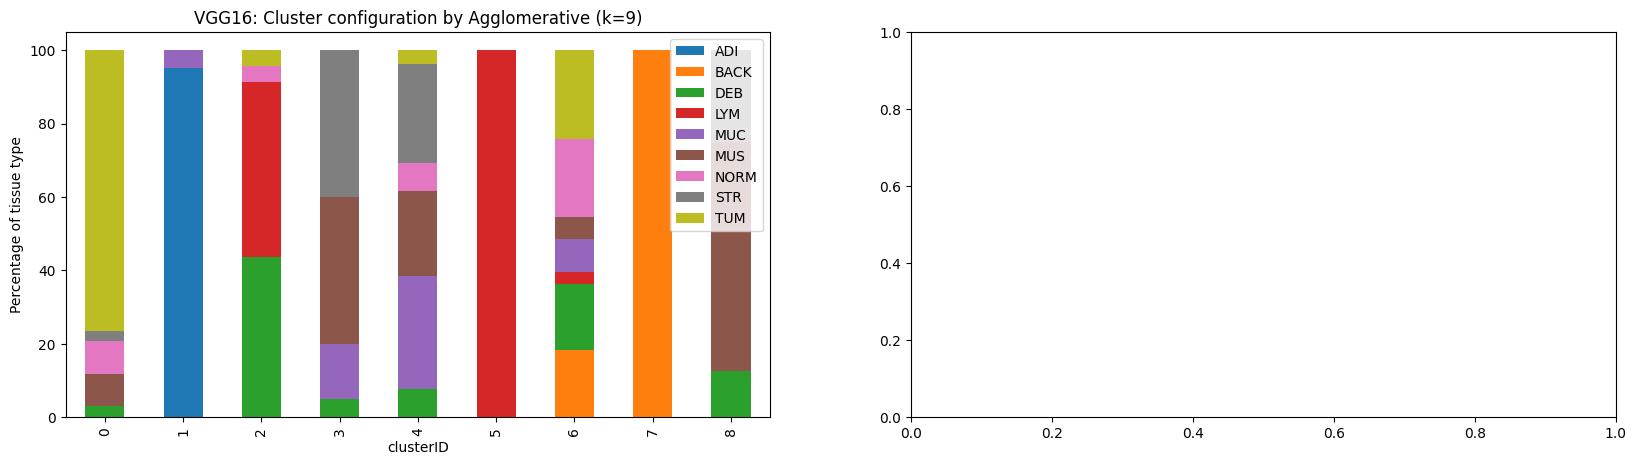

In [214]:
# === Experiment R3 – VGG16 +PCA + Agglomerative(k=3) ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sknetwork.clustering import Louvain

from sklearn.metrics import pairwise_distances, silhouette_score, v_measure_score
from sklearn.preprocessing import MinMaxScaler
from scipy import sparse

# ResNet50  & label
test_data = vgg16_pca_feature[selected_index]
test_label = labels[selected_index]

# Agglomerative
agg_model = AgglomerativeClustering(n_clusters=9)
agg_assignment = agg_model.fit_predict(test_data)

# assignment counts
agg_counts = np.unique(agg_assignment, return_counts=True)

print("VGG16 + Agglomerative assignment counts")
display(pd.DataFrame({
    'Cluster Index': agg_counts[0],
    'Number of members': agg_counts[1]
}).set_index('Cluster Index'))


agg_silhouette = silhouette_score(test_data, agg_assignment)
agg_v_measure = v_measure_score(test_label, agg_assignment)

metrics_df = pd.DataFrame({
    'Metrics': ['silhouette', 'v-measure'],
    'Agglomerative': [agg_silhouette, agg_v_measure]
}).set_index('Metrics')

print("\nEvaluation metrics (VGG16: Agglomerative)")
display(metrics_df)

# --- Agglomerative ---
resulted_cluster_df = pd.DataFrame({'clusterID': agg_assignment,
                                    'type': test_label})
label_proportion_df = (
    resulted_cluster_df
    .groupby(['clusterID'])
    .apply(lambda x: calculate_percent(x, 'type'))
    .rename(columns={'clusterID': 'type_occurrence_count'})
    .reset_index()
)
pivoted_label_proportion_df = pd.pivot_table(
    label_proportion_df,
    index='clusterID',
    columns='type',
    values='type_occurrence_count'
)

f, axes = plt.subplots(1, 2, figsize=(20, 5))

df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df * 100).loc[df_idx].plot.bar(
    stacked=True, ax=axes[0]
)

axes[0].set_ylabel('Percentage of tissue type')
axes[0].legend(loc='upper right')
axes[0].set_title('VGG16: Cluster configuration by Agglomerative (k=9)')

plt.show()


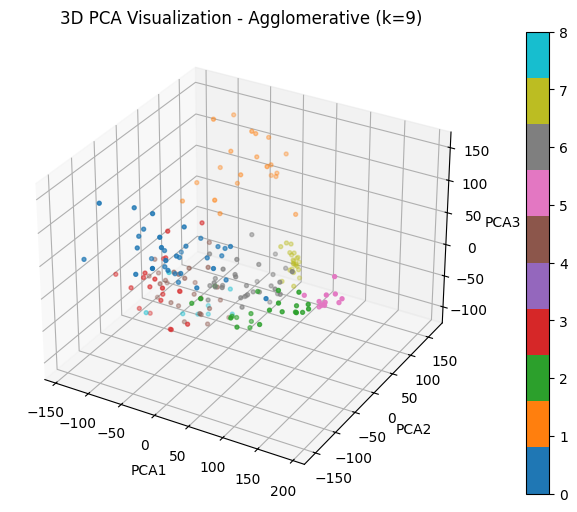

In [215]:
# Perform PCA with 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(test_data)

# Plot 3D PCA
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    pca_result[:, 2],
    c=agg_assignment,   # or louvain_assignment
    cmap='tab10',
    s=8
)

ax.set_title("3D PCA Visualization - Agglomerative (k=9)")
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
plt.colorbar(scatter)
plt.show()

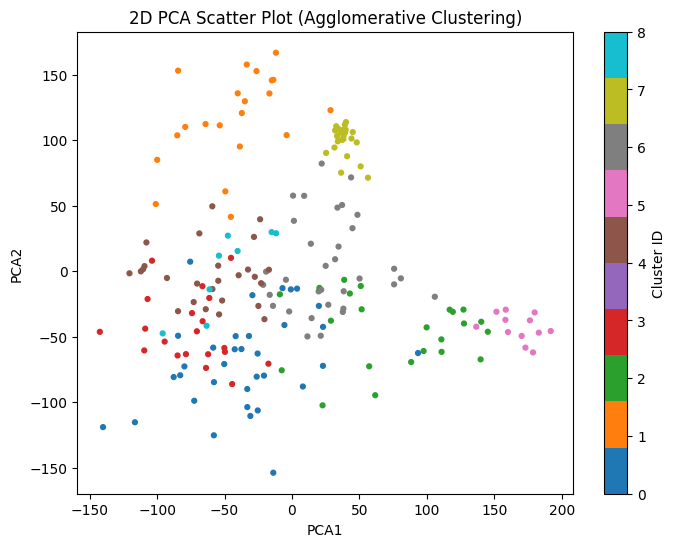

In [216]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(test_data)

# Step 2: Plot PCA coloured by Agglomerative clusters
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=agg_assignment,       # cluster labels determine colors
    cmap='tab10',
    s=12
)

plt.title("2D PCA Scatter Plot (Agglomerative Clustering)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.colorbar(label="Cluster ID")
plt.show()

VGG16 + KMeans assignment counts


c:\Users\BehShuAo\anaconda3\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



,Number of members
Cluster Index,
0,40
1,21
2,22
3,30
4,6
5,44
6,7
7,15
8,15



Evaluation metrics (VGG16: KMeans)


,KMeans
Metrics,
silhouette,0.557006
v-measure,0.720407


C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\2116290438.py:48: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



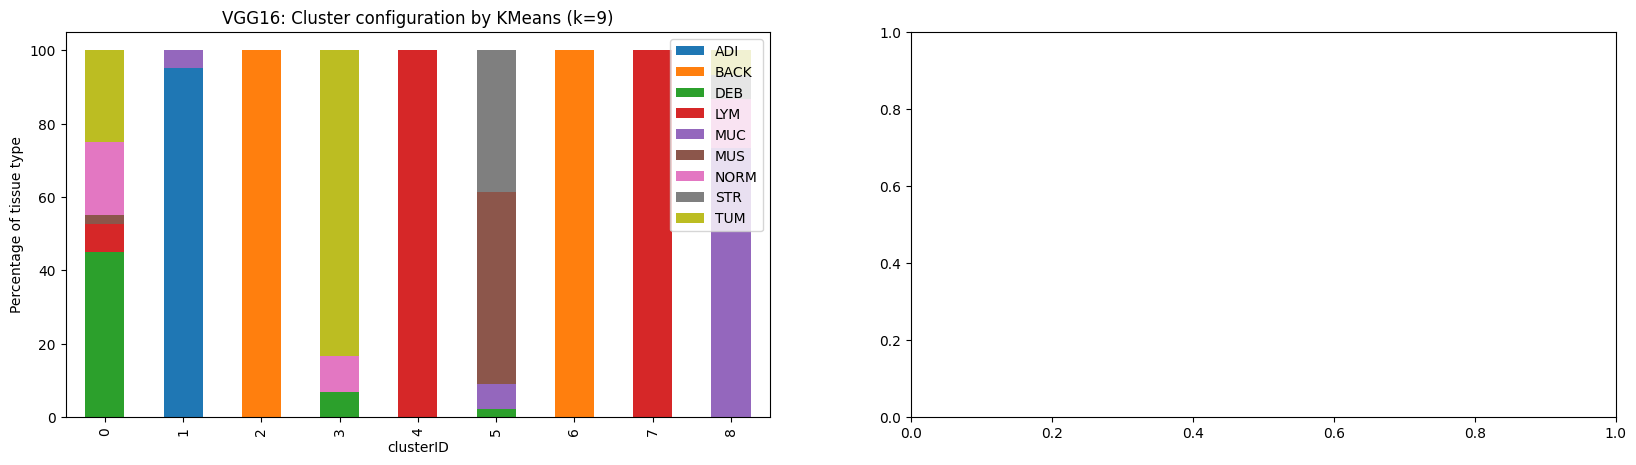

In [217]:
# === Experiment V1 – VGG16 + UMAP + KMeans(k=3) ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sknetwork.clustering import Louvain

from sklearn.metrics import pairwise_distances, silhouette_score, v_measure_score
from sklearn.preprocessing import MinMaxScaler
from scipy import sparse

test_data = vgg16_umap_feature[selected_index]
test_label = labels[selected_index]

# KMeans
kmeans_model = KMeans(n_clusters=9, random_state=0)
kmeans_assignment = kmeans_model.fit_predict(test_data)

# assignment counts
kmeans_counts = np.unique(kmeans_assignment, return_counts=True)

print("VGG16 + KMeans assignment counts")
display(pd.DataFrame({
    'Cluster Index': kmeans_counts[0],
    'Number of members': kmeans_counts[1]
}).set_index('Cluster Index'))

kmeans_silhouette = silhouette_score(test_data, kmeans_assignment)
kmeans_v_measure = v_measure_score(test_label, kmeans_assignment)

metrics_df = pd.DataFrame({
    'Metrics': ['silhouette', 'v-measure'],
    'KMeans':  [kmeans_silhouette, kmeans_v_measure]
}).set_index('Metrics')

print("\nEvaluation metrics (VGG16: KMeans)")
display(metrics_df)


# --- KMeans ---
resulted_cluster_df = pd.DataFrame({'clusterID': kmeans_assignment,
                                    'type': test_label})
label_proportion_df = (
    resulted_cluster_df
    .groupby(['clusterID'])
    .apply(lambda x: calculate_percent(x, 'type'))
    .rename(columns={'clusterID': 'type_occurrence_count'})
    .reset_index()
)
pivoted_label_proportion_df = pd.pivot_table(
    label_proportion_df,
    index='clusterID',
    columns='type',
    values='type_occurrence_count'
)

f, axes = plt.subplots(1, 2, figsize=(20, 5))

df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df * 100).loc[df_idx].plot.bar(
    stacked=True, ax=axes[0]
)

axes[0].set_ylabel('Percentage of tissue type')
axes[0].legend(loc='upper right')
axes[0].set_title('VGG16: Cluster configuration by KMeans (k=9)')


plt.show()


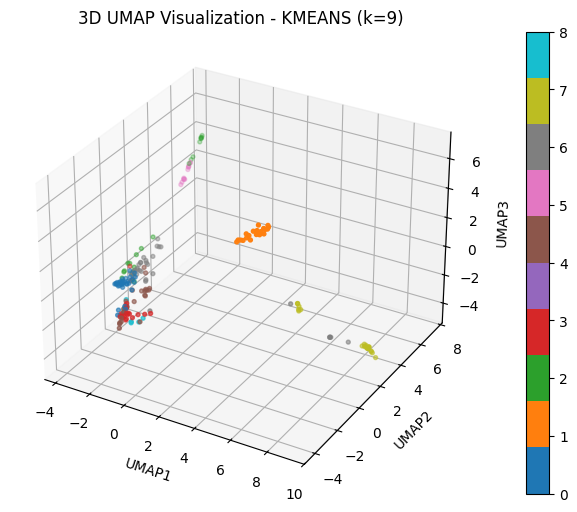

In [218]:
# Perform PCA with 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(test_data)

# Plot 3D PCA
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    pca_result[:, 2],
    c=agg_assignment,   # or louvain_assignment
    cmap='tab10',
    s=8
)

ax.set_title("3D UMAP Visualization - KMEANS (k=9)")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_zlabel("UMAP3")
plt.colorbar(scatter)
plt.show()

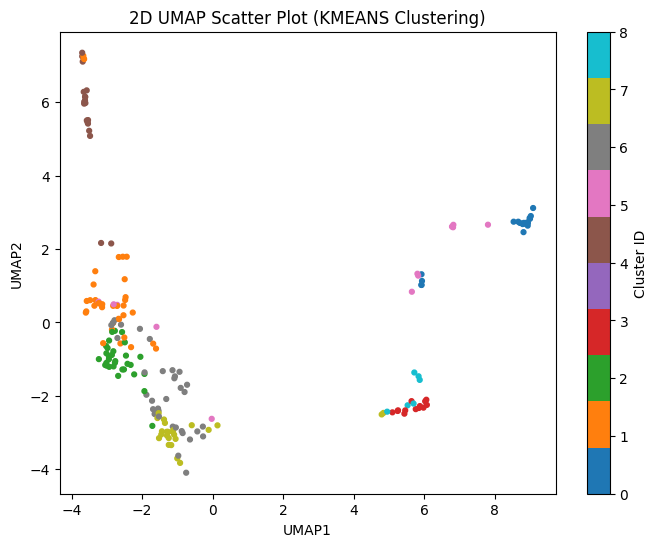

In [219]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(test_data)

# Step 2: Plot PCA coloured by Agglomerative clusters
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=gmm_assignment,       # cluster labels determine colors
    cmap='tab10',
    s=12
)

plt.title("2D UMAP Scatter Plot (KMEANS Clustering)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(label="Cluster ID")
plt.show()

VGG16+ GMM assignment counts


,Number of members
Cluster Index,
0,7
1,73
2,21
3,21
4,22
5,32
6,24



Evaluation metrics (VGG16: GMM)


,GMM
Metrics,
silhouette,0.505024
v-measure,0.690377


C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\3125380741.py:51: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



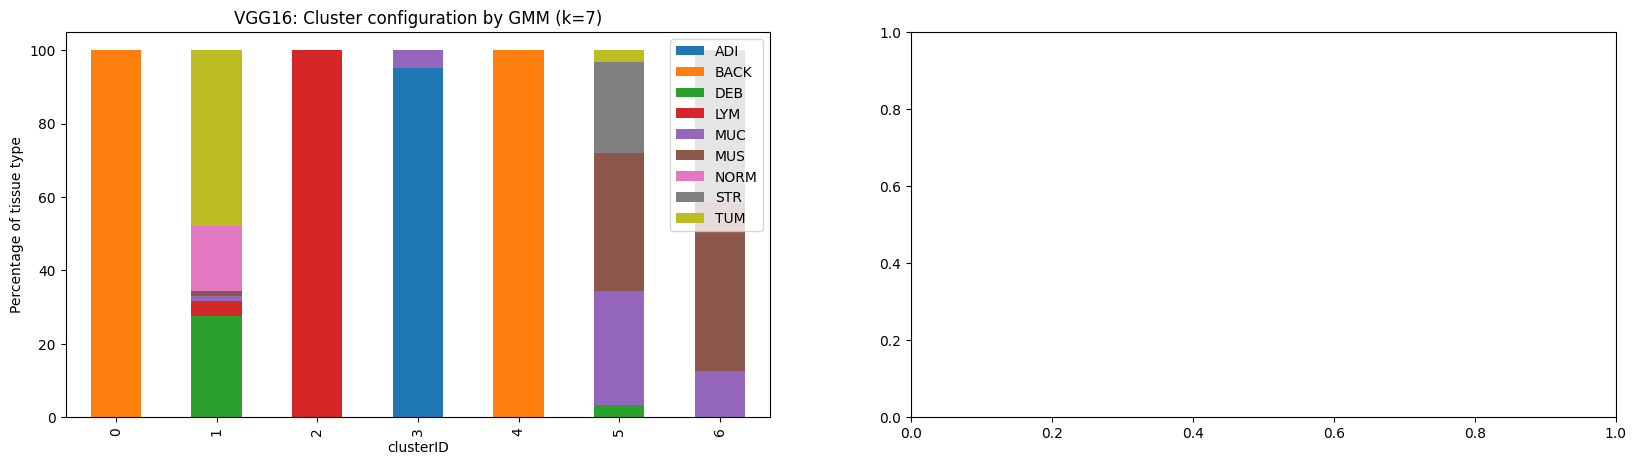

In [220]:
# === Experiment R5 – VGG16 + umap +  GMM(k=3) ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sknetwork.clustering import Louvain

from sklearn.metrics import pairwise_distances, silhouette_score, v_measure_score
from sklearn.preprocessing import MinMaxScaler
from scipy import sparse

test_data = vgg16_umap_feature[selected_index]
test_label = labels[selected_index]

# GMM
gmm_model = GaussianMixture(n_components=7, random_state=0)
gmm_assignment = gmm_model.fit_predict(test_data)

# assignment counts
gmm_counts = np.unique(gmm_assignment, return_counts=True)
louvain_counts = np.unique(louvain_assignment, return_counts=True)

print("VGG16+ GMM assignment counts")
display(pd.DataFrame({
    'Cluster Index': gmm_counts[0],
    'Number of members': gmm_counts[1]
}).set_index('Cluster Index'))


gmm_silhouette = silhouette_score(test_data, gmm_assignment)
gmm_v_measure = v_measure_score(test_label, gmm_assignment)


metrics_df = pd.DataFrame({
    'Metrics': ['silhouette', 'v-measure'],
    'GMM':     [gmm_silhouette, gmm_v_measure]
}).set_index('Metrics')

print("\nEvaluation metrics (VGG16: GMM)")
display(metrics_df)


# --- GMM ---
resulted_cluster_df = pd.DataFrame({'clusterID': gmm_assignment,
                                    'type': test_label})
label_proportion_df = (
    resulted_cluster_df
    .groupby(['clusterID'])
    .apply(lambda x: calculate_percent(x, 'type'))
    .rename(columns={'clusterID': 'type_occurrence_count'})
    .reset_index()
)
pivoted_label_proportion_df = pd.pivot_table(
    label_proportion_df,
    index='clusterID',
    columns='type',
    values='type_occurrence_count'
)

f, axes = plt.subplots(1, 2, figsize=(20, 5))

df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df * 100).loc[df_idx].plot.bar(
    stacked=True, ax=axes[0]
)

axes[0].set_ylabel('Percentage of tissue type')
axes[0].legend(loc='upper right')
axes[0].set_title('VGG16: Cluster configuration by GMM (k=7)')


plt.show()


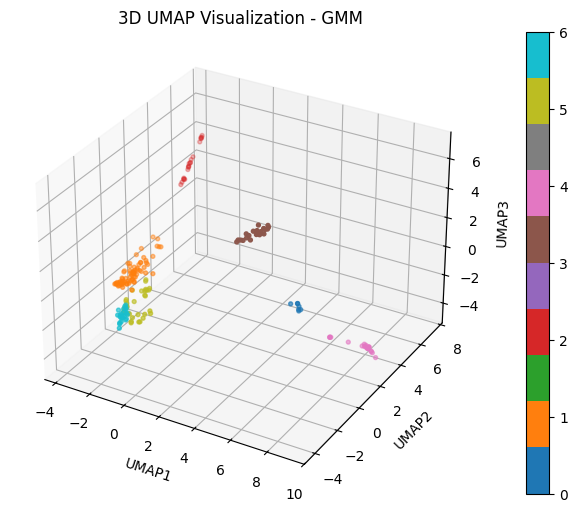

In [221]:
# Perform PCA with 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(test_data)

# Plot 3D PCA
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    pca_result[:, 2],
    c=gmm_assignment,   # or louvain_assignment
    cmap='tab10',
    s=8
)

ax.set_title("3D UMAP Visualization - GMM")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_zlabel("UMAP3")
plt.colorbar(scatter)
plt.show()

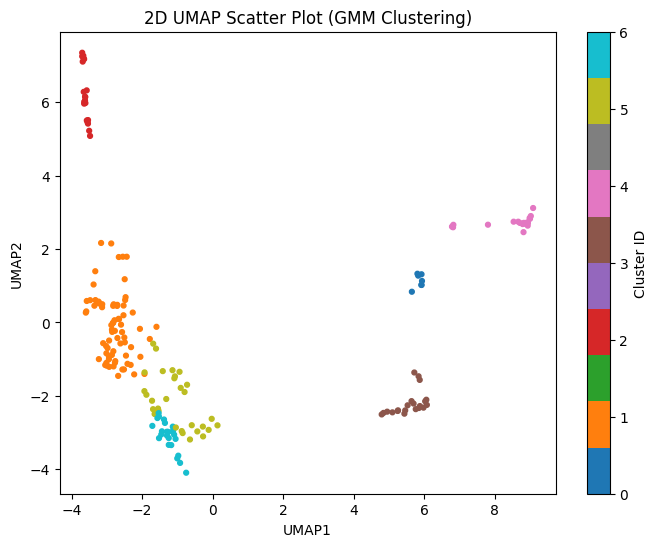

In [222]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(test_data)

# Step 2: Plot PCA coloured by Agglomerative clusters
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=gmm_assignment,       # cluster labels determine colors
    cmap='tab10',
    s=12
)

plt.title("2D UMAP Scatter Plot (GMM Clustering)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(label="Cluster ID")
plt.show()

VGG16 + Agglomerative assignment counts


,Number of members
Cluster Index,
0,46
1,22
2,7
3,40
4,15
5,21
6,30
7,13
8,6



Evaluation metrics (VGG16: Agglomerative)


,Agglomerative
Metrics,
silhouette,0.558012
v-measure,0.726082


C:\Users\BehShuAo\AppData\Local\Temp\ipykernel_46892\1405077576.py:53: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



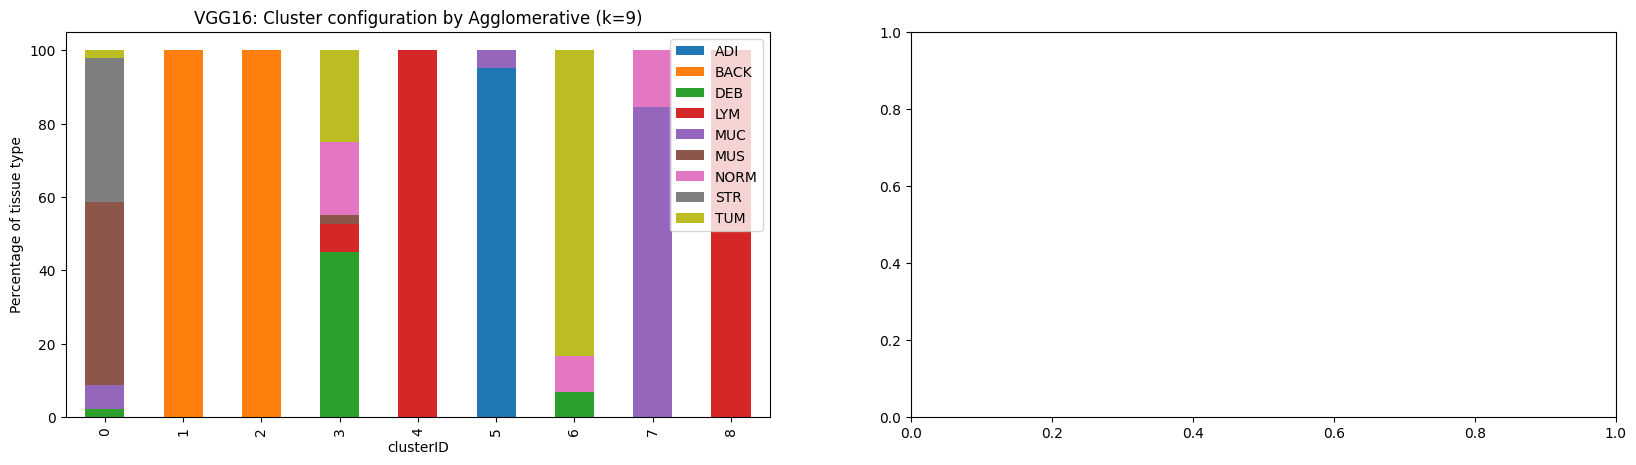

In [223]:
# === Experiment R6 – VGG16 +UMAP + Agglomerative(k=3) ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sknetwork.clustering import Louvain

from sklearn.metrics import pairwise_distances, silhouette_score, v_measure_score
from sklearn.preprocessing import MinMaxScaler
from scipy import sparse

# ResNet50  & label
test_data = vgg16_umap_feature[selected_index]
test_label = labels[selected_index]

# Agglomerative
agg_model = AgglomerativeClustering(n_clusters=9)
agg_assignment = agg_model.fit_predict(test_data)


# assignment counts
agg_counts = np.unique(agg_assignment, return_counts=True)

print("VGG16 + Agglomerative assignment counts")
display(pd.DataFrame({
    'Cluster Index': agg_counts[0],
    'Number of members': agg_counts[1]
}).set_index('Cluster Index'))



agg_silhouette = silhouette_score(test_data, agg_assignment)

agg_v_measure = v_measure_score(test_label, agg_assignment)


metrics_df = pd.DataFrame({
    'Metrics': ['silhouette', 'v-measure'],
    'Agglomerative': [agg_silhouette, agg_v_measure]
}).set_index('Metrics')

print("\nEvaluation metrics (VGG16: Agglomerative)")
display(metrics_df)

# --- Agglomerative ---
resulted_cluster_df = pd.DataFrame({'clusterID': agg_assignment,
                                    'type': test_label})
label_proportion_df = (
    resulted_cluster_df
    .groupby(['clusterID'])
    .apply(lambda x: calculate_percent(x, 'type'))
    .rename(columns={'clusterID': 'type_occurrence_count'})
    .reset_index()
)
pivoted_label_proportion_df = pd.pivot_table(
    label_proportion_df,
    index='clusterID',
    columns='type',
    values='type_occurrence_count'
)

f, axes = plt.subplots(1, 2, figsize=(20, 5))

df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df * 100).loc[df_idx].plot.bar(
    stacked=True, ax=axes[0]
)

axes[0].set_ylabel('Percentage of tissue type')
axes[0].legend(loc='upper right')
axes[0].set_title('VGG16: Cluster configuration by Agglomerative (k=9)')



plt.show()


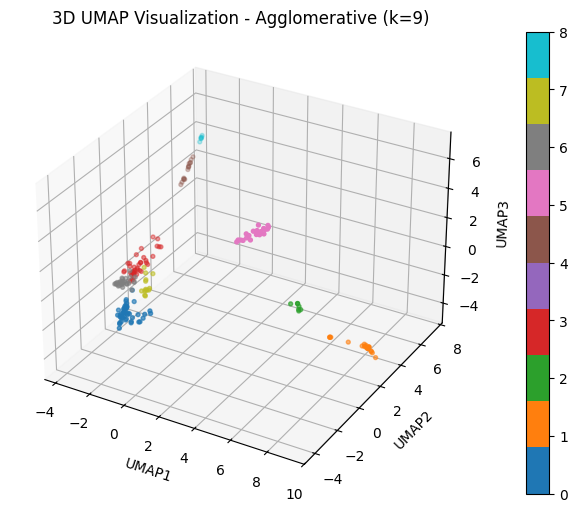

In [224]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(test_data)

# Plot 3D PCA
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    pca_result[:, 2],
    c=agg_assignment,   # or louvain_assignment
    cmap='tab10',
    s=8
)

ax.set_title("3D UMAP Visualization - Agglomerative (k=9)")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_zlabel("UMAP3")
plt.colorbar(scatter)
plt.show()

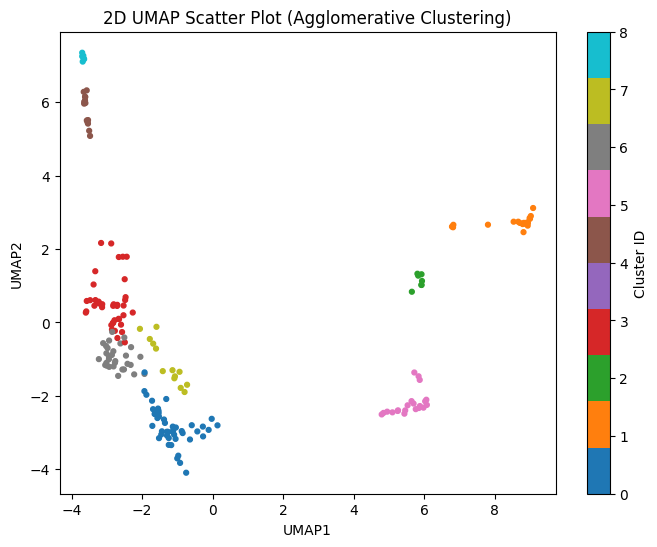

In [225]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(test_data)

# Step 2: Plot PCA coloured by Agglomerative clusters
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=agg_assignment,       # cluster labels determine colors
    cmap='tab10',
    s=12
)

plt.title("2D UMAP Scatter Plot (Agglomerative Clustering)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(label="Cluster ID")
plt.show()